# Анализ продаж авиабилетов

## Описание проекта

В проекте проведён исследовательский анализ данных о продажах авиабилетов.

Цель исследования — выявить закономерности в динамике выручки, изучить особенности поведения пассажиров и определить факторы, связанные с объёмом выручки.

В рамках анализа рассматриваются:

* динамика выручки во времени;
* структура продаж по типам пассажиров и перелётов;
* способы покупки билетов и участие в программе лояльности;
* влияние времени между покупкой билета и вылетом на выручку;
* сезонность продаж;
* наиболее популярные направления внутренних и международных перелётов;
* взаимосвязи между выручкой и другими признаками.

Для анализа используются методы предобработки данных, исследовательского анализа, визуализации и статистической проверки гипотез.

### Данные

Исходный датасет содержит информацию о продажах авиабилетов, характеристиках пассажиров и перелётов.

Для анализа городов отправления и назначения дополнительно используются данные об аэропортах из открытого датасета OpenFlights.

https://raw.githubusercontent.com/jpatokal/openflights/master/data/airports.dat

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import t, norm
from scipy import stats as st

In [ ]:
df = pd.read_csv('air_data.csv', sep=";")
df.head()

,ISSUE_DATE,FLIGHT_DATE_LOC,PAX_TYPE,REVENUE_AMOUNT,ORIG_CITY_CODE,DEST_CITY_CODE,ROUTE_FLIGHT_TYPE,FFP_FLAG,SALE_TYPE
0,2021-12-07 00:00:00,2022-01-11 00:00:00,AD,200,MOW,KGD,ВВЛ,NaN,ONLINE
1,2021-12-31 00:00:00,2022-01-03 00:00:00,AD,610,UUS,OVB,ВВЛ,NaN,OFFLINE
2,2021-11-28 00:00:00,2022-01-04 00:00:00,AD,390,KGD,MOW,ВВЛ,FFP,ONLINE
3,2021-12-08 00:00:00,2022-01-05 00:00:00,AD,190,VOZ,MOW,ВВЛ,NaN,ONLINE
4,2021-12-08 00:00:00,2022-01-12 00:00:00,AD,190,MOW,KRR,ВВЛ,FFP,OFFLINE


In [ ]:
print(f'Количество строк: {df.shape[0]}')
print(f'Количество столбцов: {df.shape[1]}')

Количество строк: 50000
Количество столбцов: 9


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   ISSUE_DATE         50000 non-null  object
 1   FLIGHT_DATE_LOC    50000 non-null  object
 2   PAX_TYPE           50000 non-null  object
 3   REVENUE_AMOUNT     50000 non-null  int64 
 4   ORIG_CITY_CODE     49998 non-null  object
 5   DEST_CITY_CODE     49999 non-null  object
 6   ROUTE_FLIGHT_TYPE  50000 non-null  object
 7   FFP_FLAG           19398 non-null  object
 8   SALE_TYPE          50000 non-null  object
dtypes: int64(1), object(8)
memory usage: 3.4+ MB


In [ ]:
df['ISSUE_DATE'] = pd.to_datetime(df['ISSUE_DATE'], format='%Y-%m-%d %H:%M:%S')
df['FLIGHT_DATE_LOC'] = pd.to_datetime(df['FLIGHT_DATE_LOC'], format='%Y-%m-%d %H:%M:%S')

In [ ]:
df.isna().sum()

,0
ISSUE_DATE,0
FLIGHT_DATE_LOC,0
PAX_TYPE,0
REVENUE_AMOUNT,0
ORIG_CITY_CODE,2
DEST_CITY_CODE,1
ROUTE_FLIGHT_TYPE,0
FFP_FLAG,30602
SALE_TYPE,0


In [ ]:
df[df['ORIG_CITY_CODE'].isna()]

,ISSUE_DATE,FLIGHT_DATE_LOC,PAX_TYPE,REVENUE_AMOUNT,ORIG_CITY_CODE,DEST_CITY_CODE,ROUTE_FLIGHT_TYPE,FFP_FLAG,SALE_TYPE
2020,2022-02-17,2022-03-22,AD,440,NaN,KHV,МВЛ,NaN,ONLINE
8100,2022-05-02,2022-05-11,AD,440,NaN,KHV,МВЛ,NaN,OFFLINE


In [ ]:
df.drop([2020, 8100], inplace = True)

In [ ]:
df[df['DEST_CITY_CODE'].isna()]

,ISSUE_DATE,FLIGHT_DATE_LOC,PAX_TYPE,REVENUE_AMOUNT,ORIG_CITY_CODE,DEST_CITY_CODE,ROUTE_FLIGHT_TYPE,FFP_FLAG,SALE_TYPE
47582,2022-05-13,2022-07-28,AD,440,KHV,NaN,МВЛ,NaN,OFFLINE


In [ ]:
df.drop([47582], inplace = True)

In [ ]:
df['FFP_FLAG'].value_counts()

,count
FFP_FLAG,
FFP,19398


In [ ]:
df['FFP_FLAG'] = df['FFP_FLAG'].fillna('NO')

In [ ]:
df.isna().sum()

,0
ISSUE_DATE,0
FLIGHT_DATE_LOC,0
PAX_TYPE,0
REVENUE_AMOUNT,0
ORIG_CITY_CODE,0
DEST_CITY_CODE,0
ROUTE_FLIGHT_TYPE,0
FFP_FLAG,0
SALE_TYPE,0


In [ ]:
df.loc[df.duplicated(keep=False)]

,ISSUE_DATE,FLIGHT_DATE_LOC,PAX_TYPE,REVENUE_AMOUNT,ORIG_CITY_CODE,DEST_CITY_CODE,ROUTE_FLIGHT_TYPE,FFP_FLAG,SALE_TYPE
337,2021-10-29,2021-11-12,AD,220,MOW,KZN,ВВЛ,FFP,ONLINE
338,2021-10-29,2021-11-12,AD,220,MOW,KZN,ВВЛ,FFP,ONLINE
649,2022-02-11,2022-08-03,AD,580,PKC,OVB,ВВЛ,NO,OFFLINE
670,2022-02-11,2022-08-03,AD,580,PKC,OVB,ВВЛ,NO,OFFLINE
716,2022-02-08,2022-08-01,AD,360,MMK,MOW,ВВЛ,NO,OFFLINE
...,...,...,...,...,...,...,...,...,...
49360,2022-03-30,2022-05-03,AD,410,MOW,OVB,ВВЛ,FFP,ONLINE
49424,2022-03-30,2022-05-03,AD,410,MOW,OVB,ВВЛ,FFP,ONLINE
49677,2022-04-02,2022-05-02,AD,470,NUX,MOW,ВВЛ,NO,ONLINE
49968,2022-06-28,2022-06-30,AD,950,MOW,HTA,ВВЛ,NO,OFFLINE


In [ ]:
df = df.query('REVENUE_AMOUNT != 0')
df.head()

,ISSUE_DATE,FLIGHT_DATE_LOC,PAX_TYPE,REVENUE_AMOUNT,ORIG_CITY_CODE,DEST_CITY_CODE,ROUTE_FLIGHT_TYPE,FFP_FLAG,SALE_TYPE
0,2021-12-07,2022-01-11,AD,200,MOW,KGD,ВВЛ,NO,ONLINE
1,2021-12-31,2022-01-03,AD,610,UUS,OVB,ВВЛ,NO,OFFLINE
2,2021-11-28,2022-01-04,AD,390,KGD,MOW,ВВЛ,FFP,ONLINE
3,2021-12-08,2022-01-05,AD,190,VOZ,MOW,ВВЛ,NO,ONLINE
4,2021-12-08,2022-01-12,AD,190,MOW,KRR,ВВЛ,FFP,OFFLINE


Вывод

Датасет имеет 50000 строк и 9 столбцов

Пропуски были в трех столбцах. В столбцах по городам отправления и прибытия строки я просто удалила, потому что невозможно достоверно предположить, какой город там должен быть. В столбце наличия программы лояльности в пропусках было решено обозначить, что программы лояльности просто нет, потому что до этого там было всего уникальное значение, что заставляет думать, что оно означает просто наличие программы лояльности

В данных не было замечено различие во времени, поэтому столбцы с датами были преобразованы в столбцы без указания времени. В датасете нет каких-то уникальных значений, которые не могут повторяться. Более того – полные дубликаты могут быть (их всего 333), потому что несколько людей могут купить в один день билет, а затем – улететь в один день


In [ ]:
df['ISSUE_DATE_YM'] = df['ISSUE_DATE'].astype(str).str[:7]
df.head()

,ISSUE_DATE,FLIGHT_DATE_LOC,PAX_TYPE,REVENUE_AMOUNT,ORIG_CITY_CODE,DEST_CITY_CODE,ROUTE_FLIGHT_TYPE,FFP_FLAG,SALE_TYPE,ISSUE_DATE_YM
0,2021-12-07,2022-01-11,AD,200,MOW,KGD,ВВЛ,NO,ONLINE,2021-12
1,2021-12-31,2022-01-03,AD,610,UUS,OVB,ВВЛ,NO,OFFLINE,2021-12
2,2021-11-28,2022-01-04,AD,390,KGD,MOW,ВВЛ,FFP,ONLINE,2021-11
3,2021-12-08,2022-01-05,AD,190,VOZ,MOW,ВВЛ,NO,ONLINE,2021-12
4,2021-12-08,2022-01-12,AD,190,MOW,KRR,ВВЛ,FFP,OFFLINE,2021-12


In [ ]:
revenue = (df.pivot_table(index='ISSUE_DATE_YM', aggfunc='sum', values='REVENUE_AMOUNT')).reset_index()
revenue

,ISSUE_DATE_YM,REVENUE_AMOUNT
0,2021-10,1334610
1,2021-11,1857880
2,2021-12,1767190
3,2022-01,1363860
4,2022-02,1354660
5,2022-03,1833890
6,2022-04,2040720
7,2022-05,1714210
8,2022-06,1616250
9,2022-07,2643660


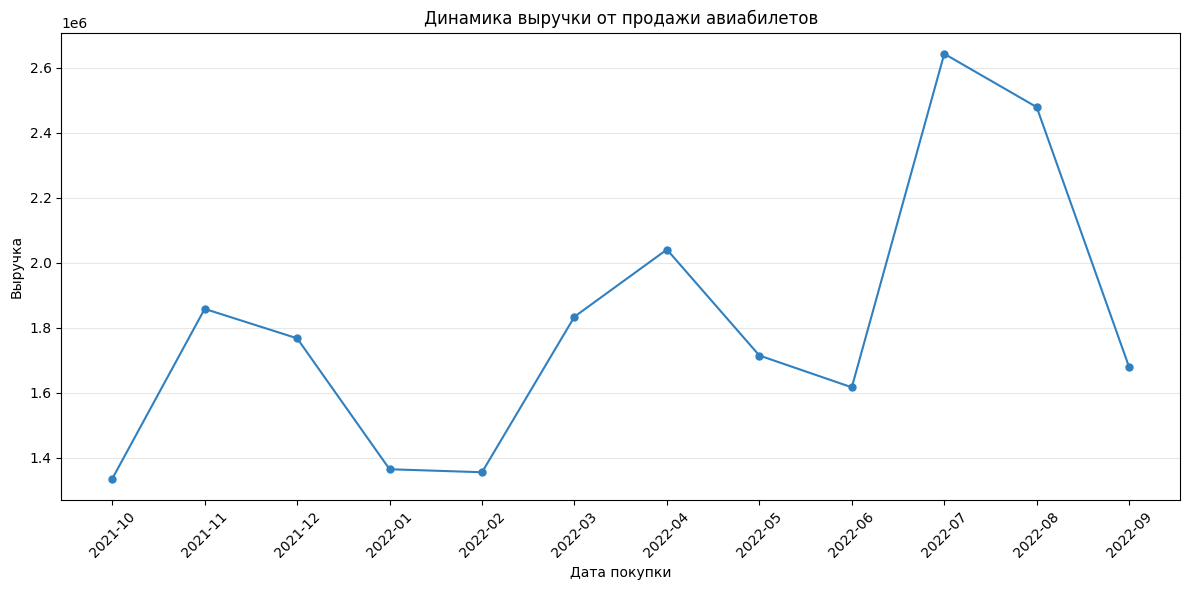

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    revenue['ISSUE_DATE_YM'],
    revenue['REVENUE_AMOUNT'],
    color='#2F80C0',
    marker='o',
    markersize=5
)

plt.title('Динамика выручки от продажи авиабилетов')
plt.xlabel('Дата покупки')
plt.ylabel('Выручка')

plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [37]:
revenue_new = (df.pivot_table(index=['ISSUE_DATE_YM', 'FFP_FLAG', 'ROUTE_FLIGHT_TYPE', 'SALE_TYPE'], aggfunc='sum', values='REVENUE_AMOUNT')).reset_index()
revenue_new

,ISSUE_DATE_YM,FFP_FLAG,ROUTE_FLIGHT_TYPE,SALE_TYPE,REVENUE_AMOUNT
0,2021-10,FFP,ВВЛ,OFFLINE,138200
1,2021-10,FFP,ВВЛ,ONLINE,305800
2,2021-10,FFP,МВЛ,OFFLINE,11310
3,2021-10,FFP,МВЛ,ONLINE,48810
4,2021-10,NO,ВВЛ,OFFLINE,348320
...,...,...,...,...,...
90,2022-09,FFP,МВЛ,ONLINE,7370
91,2022-09,NO,ВВЛ,OFFLINE,657340
92,2022-09,NO,ВВЛ,ONLINE,350440
93,2022-09,NO,МВЛ,OFFLINE,74680


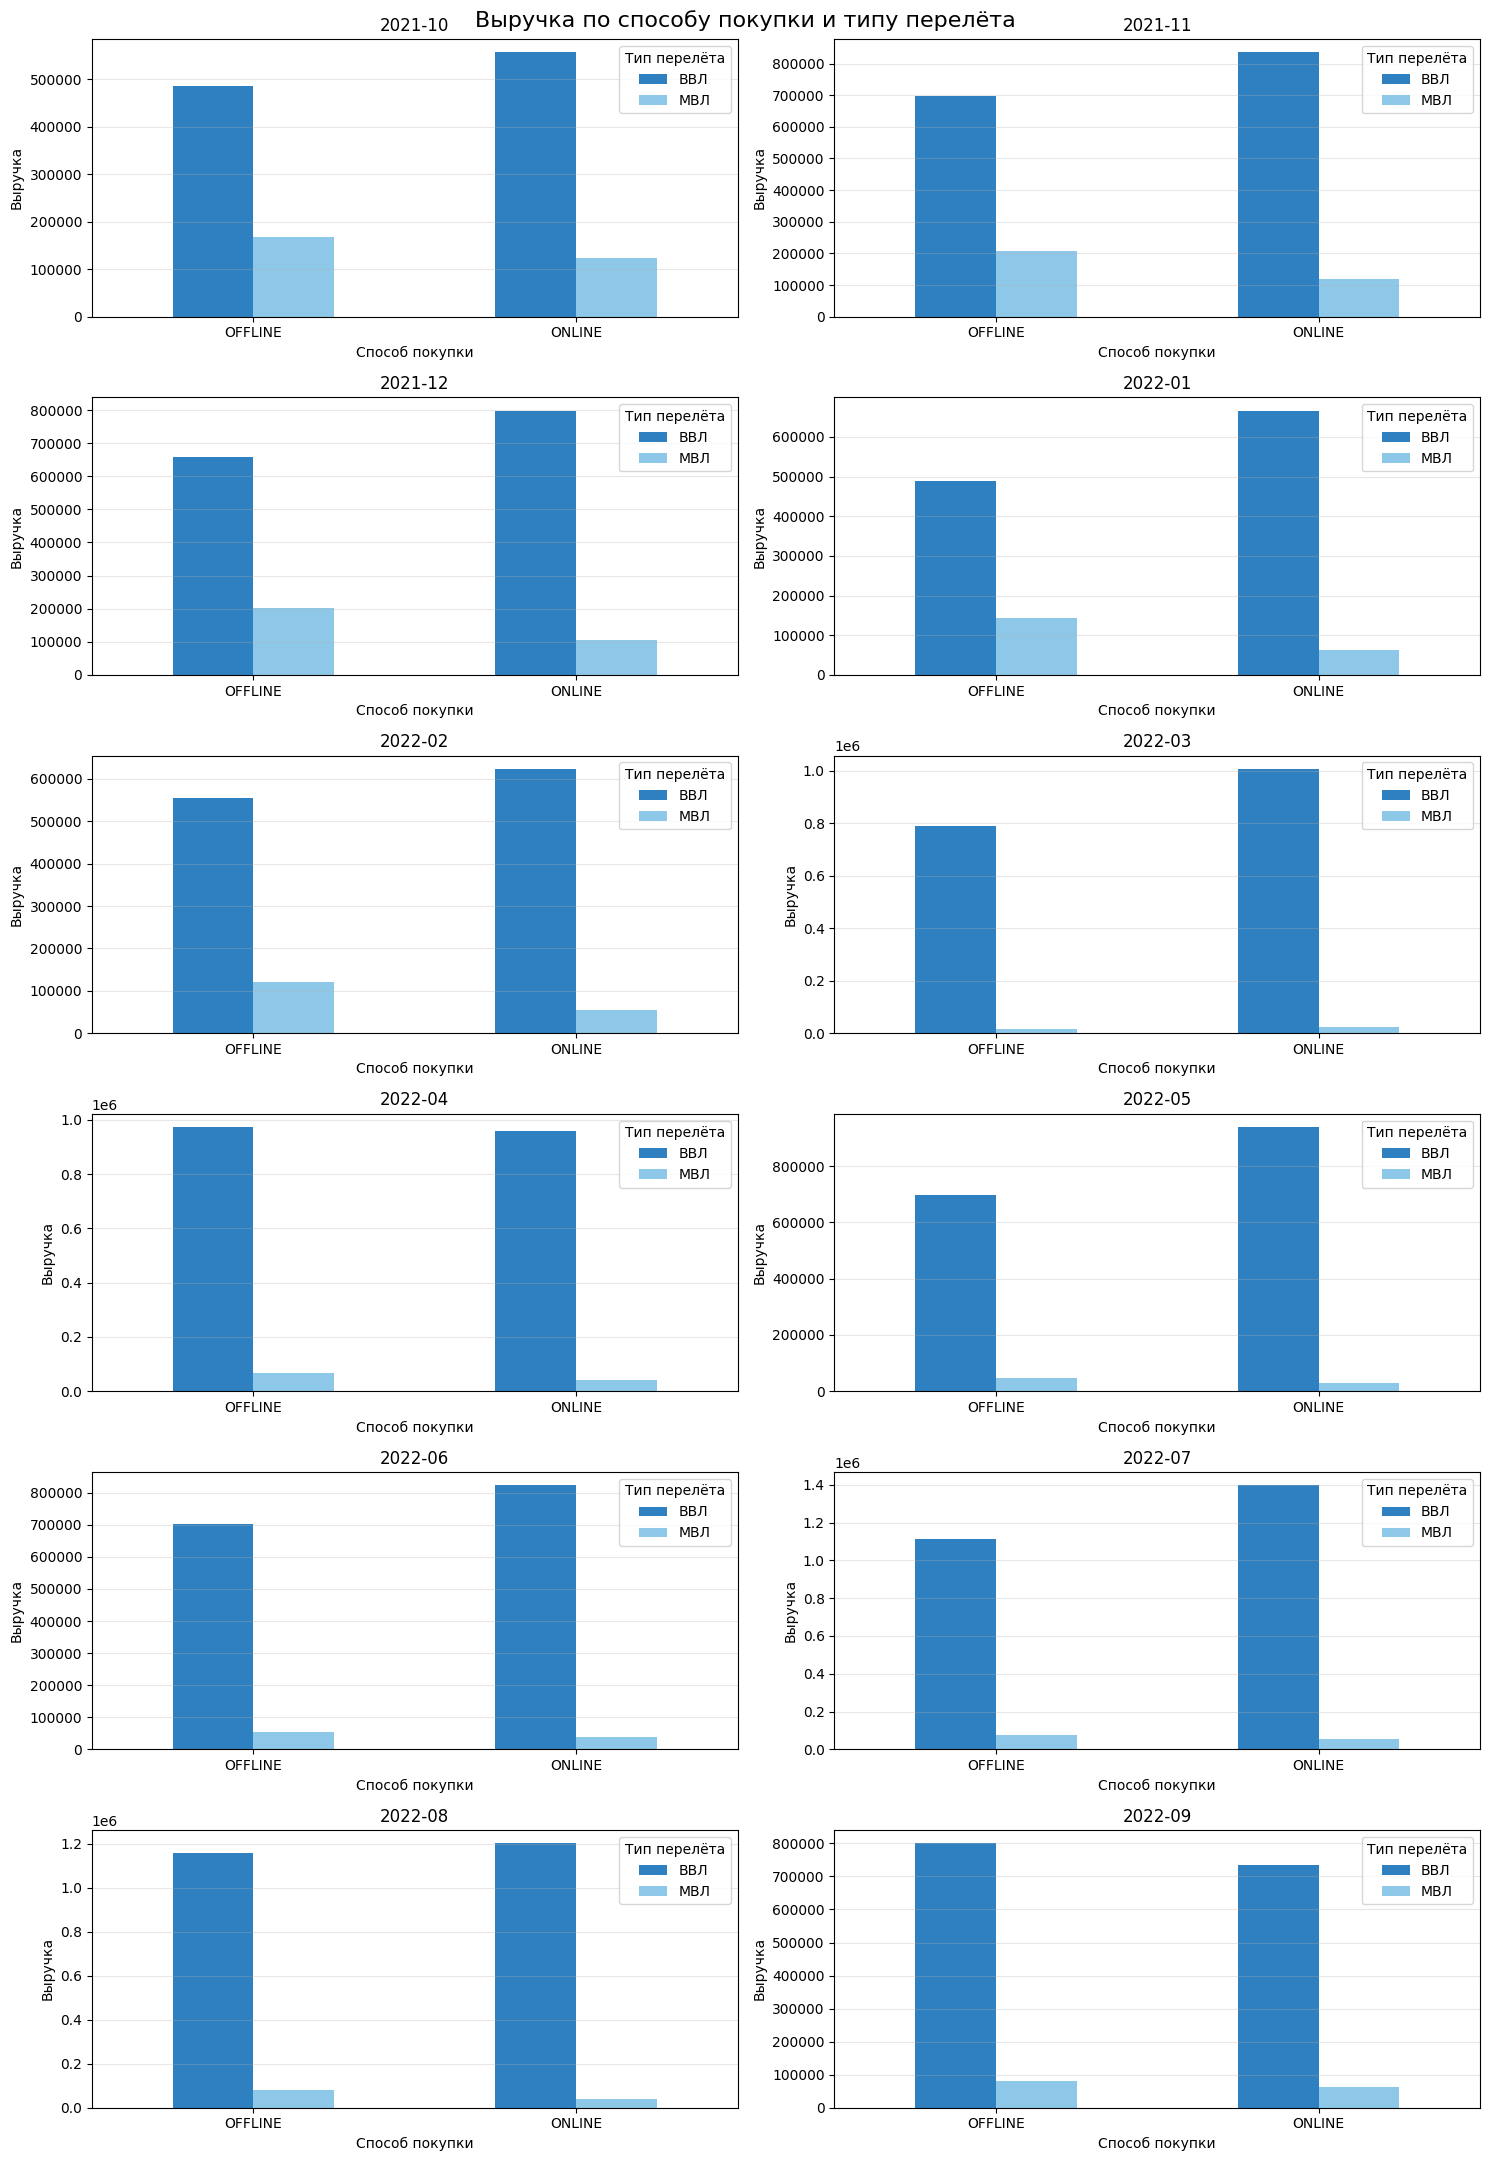

In [38]:
dates = revenue_new['ISSUE_DATE_YM'].unique()

fig, axs = plt.subplots(6, 2, figsize=(15, 22))
axs = axs.flatten()

colors = ['#2F80C0', '#8EC8E8']

for i, date in enumerate(dates):
    df_date = revenue_new.query('ISSUE_DATE_YM == @date')

    grouped = (
        df_date
        .groupby(['SALE_TYPE', 'ROUTE_FLIGHT_TYPE'])['REVENUE_AMOUNT']
        .sum()
        .unstack()
    )

    grouped.plot(
        kind='bar',
        ax=axs[i],
        color=colors
    )

    axs[i].set_title(str(date))
    axs[i].set_xlabel('Способ покупки')
    axs[i].set_ylabel('Выручка')

    axs[i].grid(axis='y', alpha=0.3)
    axs[i].tick_params(axis='x', rotation=0)

    axs[i].legend(title='Тип перелёта')

fig.suptitle(
    'Выручка по способу покупки и типу перелёта',
    fontsize=16
)

plt.tight_layout()
plt.show()

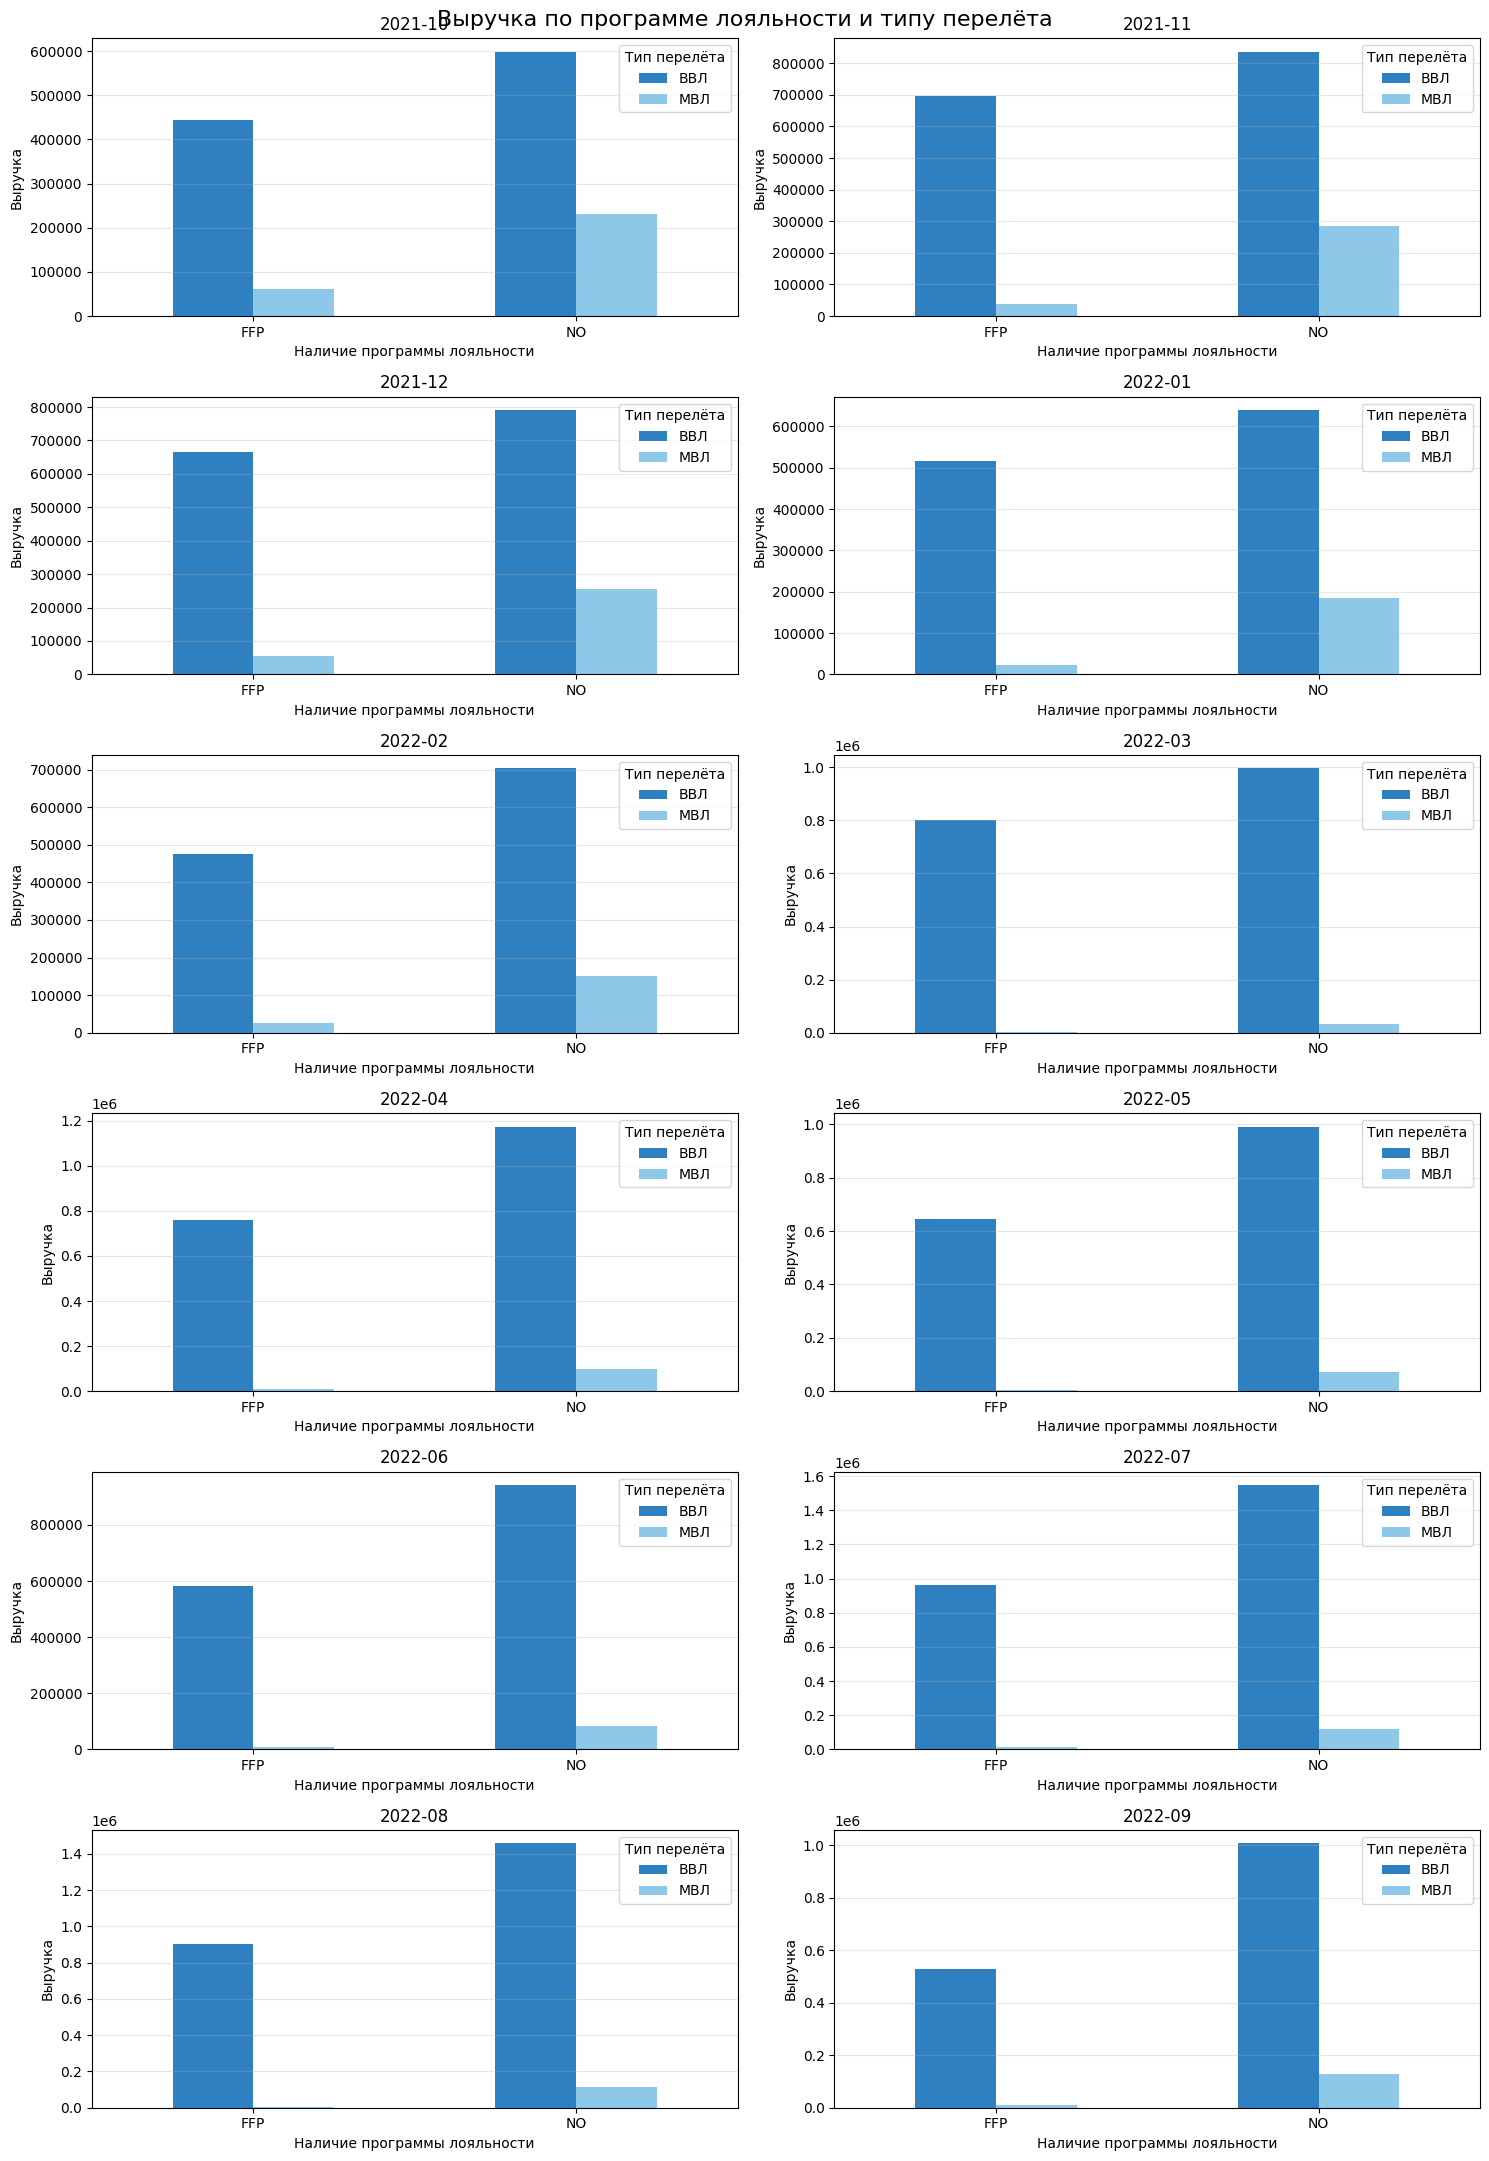

In [39]:
fig, axs = plt.subplots(6, 2, figsize=(15, 22))
axs = axs.flatten()

colors = ['#2F80C0', '#8EC8E8']

for i, date in enumerate(dates):
    df_date = revenue_new.query('ISSUE_DATE_YM == @date')

    grouped_ffp = (
        df_date
        .groupby(['FFP_FLAG', 'ROUTE_FLIGHT_TYPE'])['REVENUE_AMOUNT']
        .sum()
        .unstack()
    )

    grouped_ffp.plot(
        kind='bar',
        ax=axs[i],
        color=colors
    )

    axs[i].set_title(str(date))
    axs[i].set_xlabel('Наличие программы лояльности')
    axs[i].set_ylabel('Выручка')

    axs[i].grid(axis='y', alpha=0.3)
    axs[i].tick_params(axis='x', rotation=0)

    axs[i].legend(title='Тип перелёта')

for j in range(len(dates), len(axs)):
    axs[j].set_visible(False)

fig.suptitle(
    'Выручка по программе лояльности и типу перелёта',
    fontsize=16
)

plt.tight_layout()
plt.show()

In [40]:
revenue_sale_type = (df.pivot_table(index=['ISSUE_DATE_YM', 'SALE_TYPE'], aggfunc='sum', values='REVENUE_AMOUNT'))
revenue_sale_type.head(6)

REVENUE_AMOUNT
ISSUE_DATE_YM SALE_TYPE                
2021-10       OFFLINE            654730
              ONLINE             679880
2021-11       OFFLINE            904670
              ONLINE             953210
2021-12       OFFLINE            862000
              ONLINE             905190

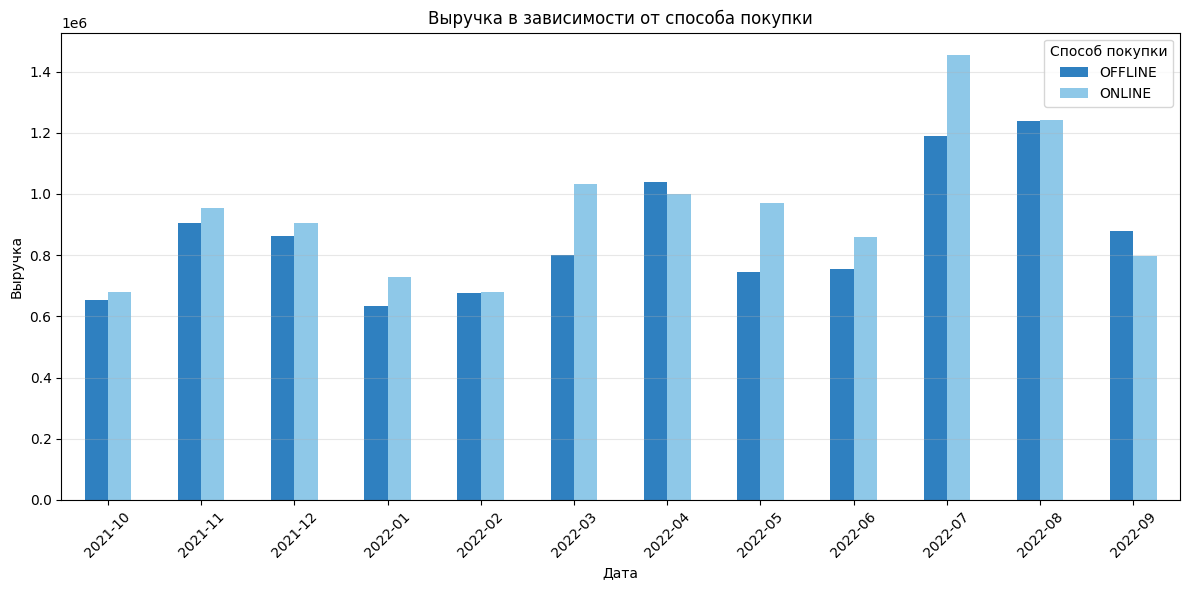

In [91]:
ax = revenue_sale_type.unstack().plot(
    kind='bar',
    figsize=(12, 6),
    color=['#2F80C0', '#8EC8E8']
)

ax.set_title('Выручка в зависимости от способа покупки')
ax.set_xlabel('Дата')
ax.set_ylabel('Выручка')

ax.grid(axis='y', alpha=0.3)

ax.legend(title='Способ покупки', labels=['OFFLINE', 'ONLINE'])

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [92]:
revenue_pax_type = (df.pivot_table(index=['ISSUE_DATE_YM', 'PAX_TYPE'], aggfunc='sum', values='REVENUE_AMOUNT')).reset_index()
revenue_pax_type.head(6)

,ISSUE_DATE_YM,PAX_TYPE,REVENUE_AMOUNT
0,2021-10,AD,1251490
1,2021-10,CHD,81200
2,2021-10,INF,1920
3,2021-11,AD,1751190
4,2021-11,CHD,105950
5,2021-11,INF,740


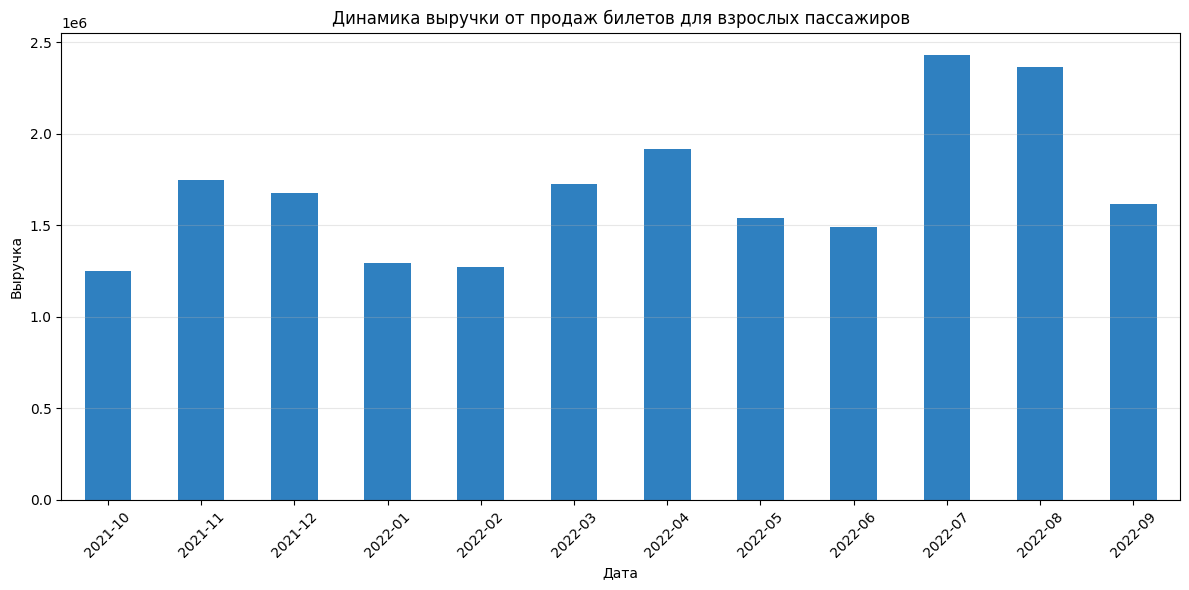

In [93]:
df_ad = df[df['PAX_TYPE'] == 'AD']

revenue_pax_type_ad = df_ad.pivot_table(
    index='ISSUE_DATE_YM',
    values='REVENUE_AMOUNT',
    aggfunc='sum'
)

ax = revenue_pax_type_ad.plot(
    kind='bar',
    figsize=(12, 6),
    color='#2F80C0'
)

ax.set_title('Динамика выручки от продаж билетов для взрослых пассажиров')
ax.set_xlabel('Дата')
ax.set_ylabel('Выручка')

ax.grid(axis='y', alpha=0.3)

plt.legend().set_visible(False)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

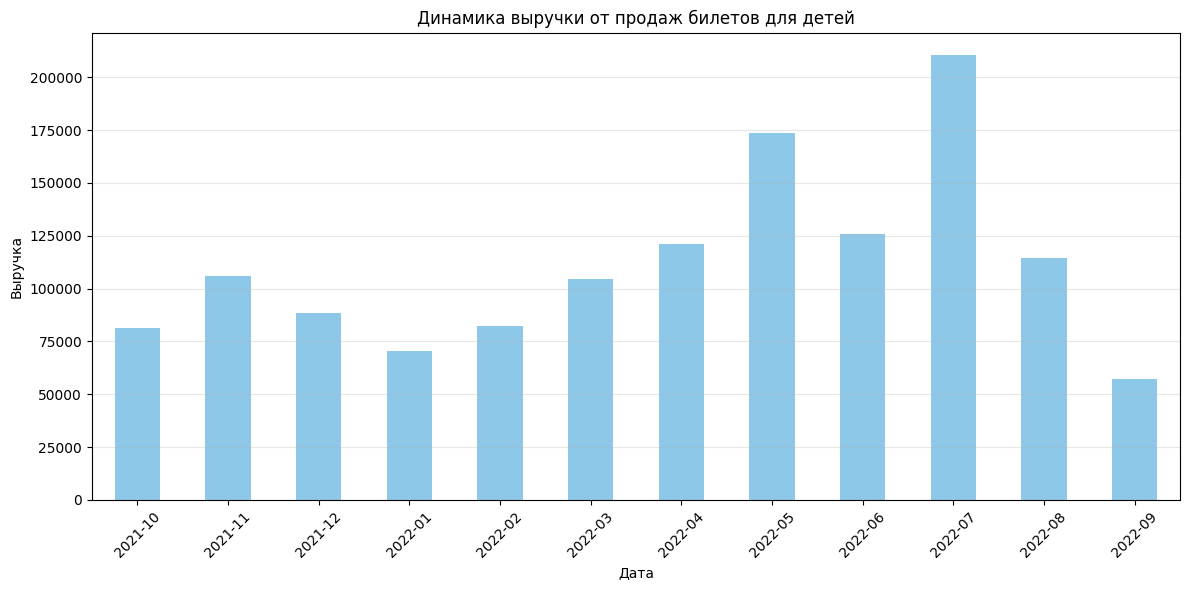

In [94]:
df_chd = df[df['PAX_TYPE'] == 'CHD']

revenue_pax_type_chd = df_chd.pivot_table(
    index='ISSUE_DATE_YM',
    values='REVENUE_AMOUNT',
    aggfunc='sum'
)

ax = revenue_pax_type_chd.plot(
    kind='bar',
    figsize=(12, 6),
    color='#8EC8E8'
)

ax.set_title('Динамика выручки от продаж билетов для детей')
ax.set_xlabel('Дата')
ax.set_ylabel('Выручка')

ax.grid(axis='y', alpha=0.3)

plt.legend().set_visible(False)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [96]:
revenue_ffp = (df.pivot_table(index=['ISSUE_DATE_YM', 'FFP_FLAG'], aggfunc='sum', values='REVENUE_AMOUNT'))
revenue_ffp.head(4)

REVENUE_AMOUNT
ISSUE_DATE_YM FFP_FLAG                
2021-10       FFP               504120
              NO                830490
2021-11       FFP               736010
              NO               1121870

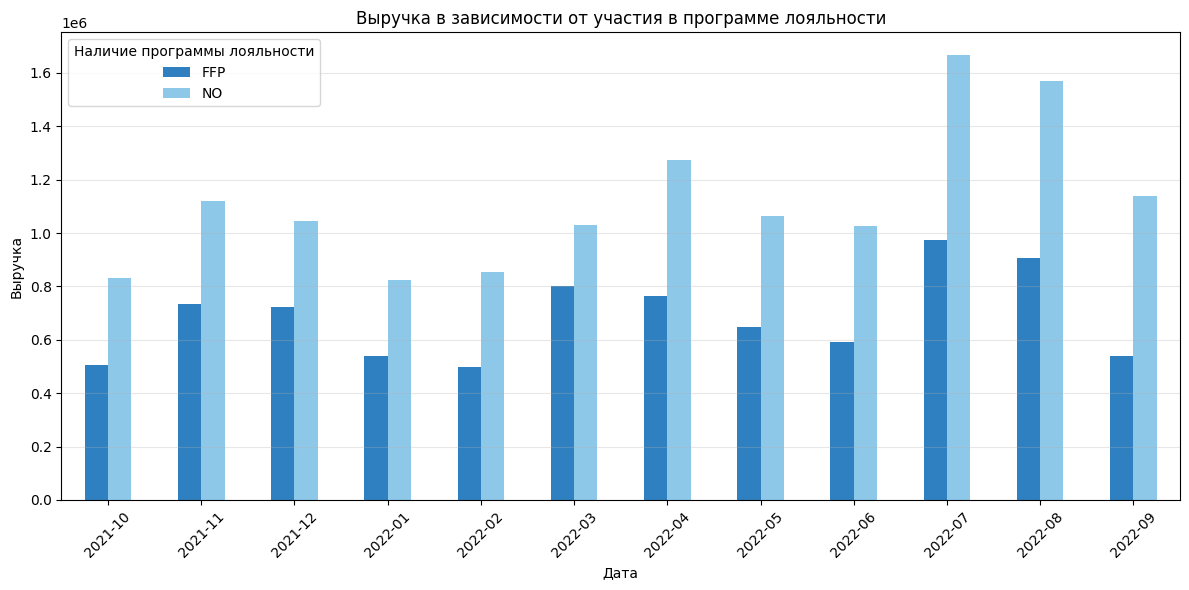

In [97]:
ax = revenue_ffp.unstack().plot(
    kind='bar',
    figsize=(12, 6),
    color=['#2F80C0', '#8EC8E8']
)

ax.set_title('Выручка в зависимости от участия в программе лояльности')
ax.set_xlabel('Дата')
ax.set_ylabel('Выручка')

ax.grid(axis='y', alpha=0.3)

ax.legend(title='Программа лояльности')

plt.legend(title='Наличие программы лояльности', labels=['FFP', 'NO'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [47]:
revenue_rft = (df.pivot_table(index=['ISSUE_DATE_YM', 'ROUTE_FLIGHT_TYPE'], aggfunc='sum', values='REVENUE_AMOUNT'))
revenue_rft.head(4)

REVENUE_AMOUNT
ISSUE_DATE_YM ROUTE_FLIGHT_TYPE                
2021-10       ВВЛ                       1042770
              МВЛ                        291840
2021-11       ВВЛ                       1533700
              МВЛ                        324180

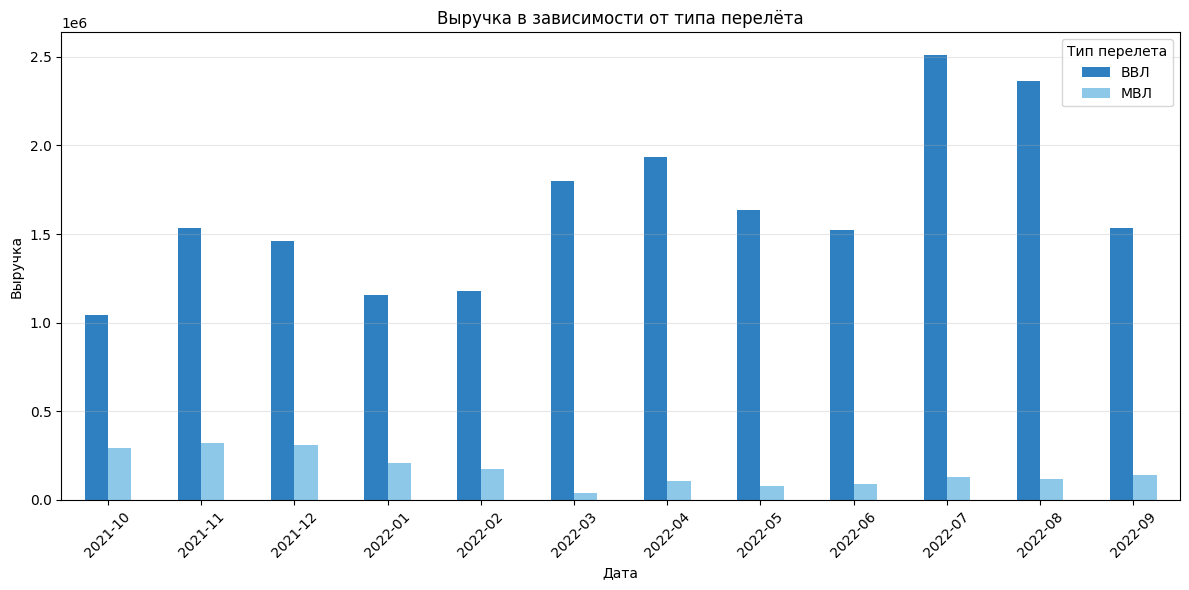

In [98]:
ax = revenue_rft.unstack().plot(
    kind='bar',
    figsize=(12, 6),
    color=['#2F80C0', '#8EC8E8']
)

ax.set_title('Выручка в зависимости от типа перелёта')
ax.set_xlabel('Дата')
ax.set_ylabel('Выручка')

ax.grid(axis='y', alpha=0.3)

ax.legend(title='Тип перелета', labels=['ВВЛ', 'МВЛ'])

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Выводы:

Проанализировав динамику выручки от продажи билетов, можно сделать вывод, что самые высокие продажи были в июле 2022 года. Это может быть связано с тем, что после возникновения некоторых политических обстоятельств стало намного дороже пользоваться авиаперелетами, так как, чтобы добраться до многих заграничных городов, приходилось летать пересадками. А некоторые люди просто переключились на путешествия внутри страны, из-за чего больше стали тратить именно на это

Если взглянуть на графики выручки в зависимости от способа покупки и типа перелета по каждому году, то можно сделать вывод, что больше билеты покупают онлайн и именно для перелетов внутри страны. Тут также можно заметить, что в целом покупок билетов на международные рейсы стало меньше, начиная с марта 2022 года, что так же связано с политическими обстоятельствами

Если взглянуть на графики выручки в зависимости от наличия программы лояльности и типа перелета по каждому году, то видно, что по большей части люди летают, не пользуясь программами лояльности. Это может быть связано с тем, что их в целом мало, а также – с тем, что не все люди знают об их существовании

Если смотреть на графики выручки только от способа покупки по годам, то видно, что больше всего покупок билетов было в июле и августе 2022 года. Причем, в июле больше билетов купили онлайн, а в августе примерно одинаковое количество людей купили билеты офлайн и онлайн

Если анализировать продажи авиабилетов по каждому типу пассажиров, то можно заметить, что есть разрыв динамики покупок билетов для взрослых и детей есть в августе 2022 года. Возможно это связано с тем, что в июле чаще ездят отдыхать с детьми, так как у них разгар каникул. При этом очень много покупок билетов неизвестным типом пассажиров было в октябре 2021 года. Возможно тогда необязательно было фиксировать в отчетности данную информацию

Если анализировать продажи авиабилетов только по наличию программы лояльности, то можно заметить, что независимо и с программой лояльности, и без нее больше покупали билетов в июле 2022 года

Если анализировать продажи авиабилетов только по типу перелета, то можно прямо увидеть тенденцию к снижению покупок билетов на международные рейсы, а потом постепенное увеличение, что связано так же с политическими причинами


In [49]:
df['REVENUE_AMOUNT'].describe()

,REVENUE_AMOUNT
count,49531.000000
mean,437.798752
std,214.845142
min,10.000000
25%,290.000000
50%,400.000000
75%,550.000000
max,5200.000000


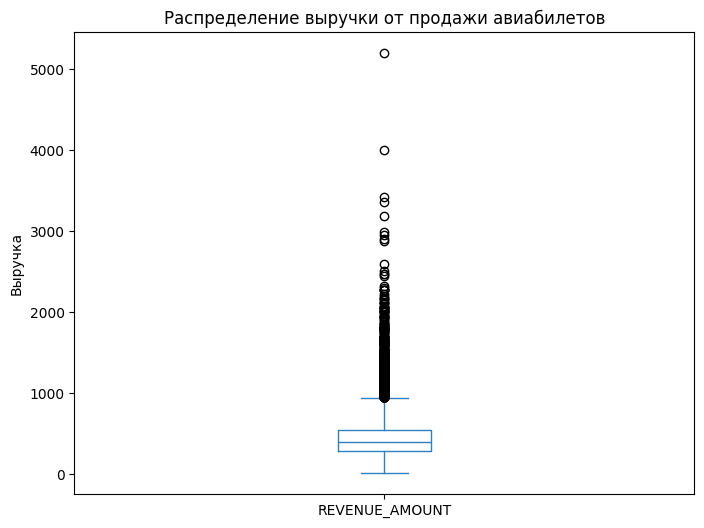

In [50]:
ax = df['REVENUE_AMOUNT'].plot(
    kind='box',
    figsize=(8, 6),
    color='#2F80C0'
)

ax.set_title('Распределение выручки от продажи авиабилетов')
ax.set_ylabel('Выручка')

plt.show()

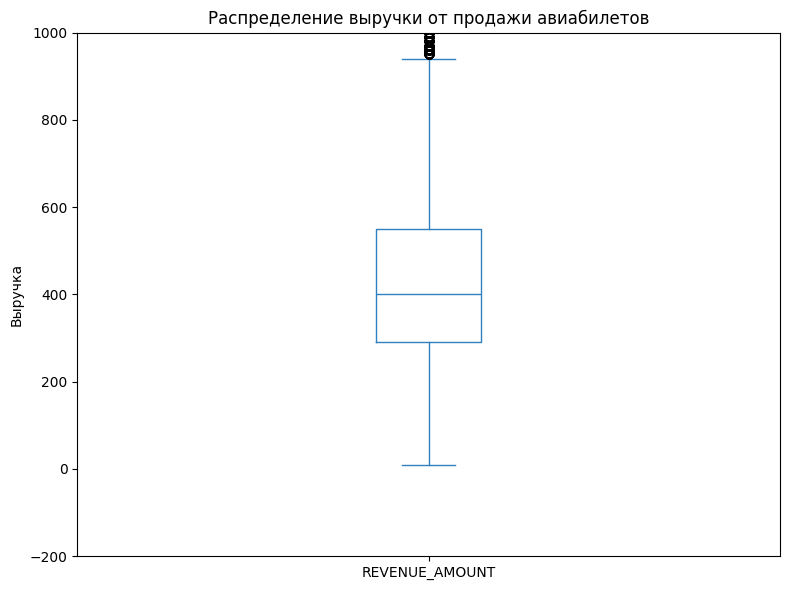

In [51]:
ax = df['REVENUE_AMOUNT'].plot(
    kind='box',
    ylim=(-200, 1000),
    figsize=(8, 6),
    color='#2F80C0'
)

ax.set_title('Распределение выручки от продажи авиабилетов')
ax.set_ylabel('Выручка')

plt.tight_layout()
plt.show()

In [52]:
q75 = np.percentile(df['REVENUE_AMOUNT'], 75)
q25 = np.percentile(df['REVENUE_AMOUNT'],25)

iqr = np.percentile(df['REVENUE_AMOUNT'],75) - np.percentile(df['REVENUE_AMOUNT'],25)
ejection_h = q75+1.5*iqr
ejection_l = q25-1.5*iqr

print (ejection_h, ejection_l)

940.0 -100.0


In [53]:
n_ejection = df['REVENUE_AMOUNT'][(df['REVENUE_AMOUNT'] > ejection_h) | (df['REVENUE_AMOUNT'] < ejection_l)].count()
print('Число выбросов:', n_ejection)

Число выбросов: 1000


In [54]:
df_good = df[(df['REVENUE_AMOUNT'] > ejection_l) & (df['REVENUE_AMOUNT']  < ejection_h)]
df_good = df_good.reset_index(drop=True)
df_good.head(3)

,ISSUE_DATE,FLIGHT_DATE_LOC,PAX_TYPE,REVENUE_AMOUNT,ORIG_CITY_CODE,DEST_CITY_CODE,ROUTE_FLIGHT_TYPE,FFP_FLAG,SALE_TYPE,ISSUE_DATE_YM
0,2021-12-07,2022-01-11,AD,200,MOW,KGD,ВВЛ,NO,ONLINE,2021-12
1,2021-12-31,2022-01-03,AD,610,UUS,OVB,ВВЛ,NO,OFFLINE,2021-12
2,2021-11-28,2022-01-04,AD,390,KGD,MOW,ВВЛ,FFP,ONLINE,2021-11


In [55]:
n_ejection = df_good['REVENUE_AMOUNT'][(df_good['REVENUE_AMOUNT'] > ejection_h) | (df_good['REVENUE_AMOUNT'] < ejection_l)].count()
print('Число выбросов:', n_ejection)

Число выбросов: 0


In [56]:
df_good['REVENUE_AMOUNT'].describe()

,REVENUE_AMOUNT
count,48476.000000
mean,421.377589
std,177.806728
min,10.000000
25%,280.000000
50%,400.000000
75%,540.000000
max,930.000000


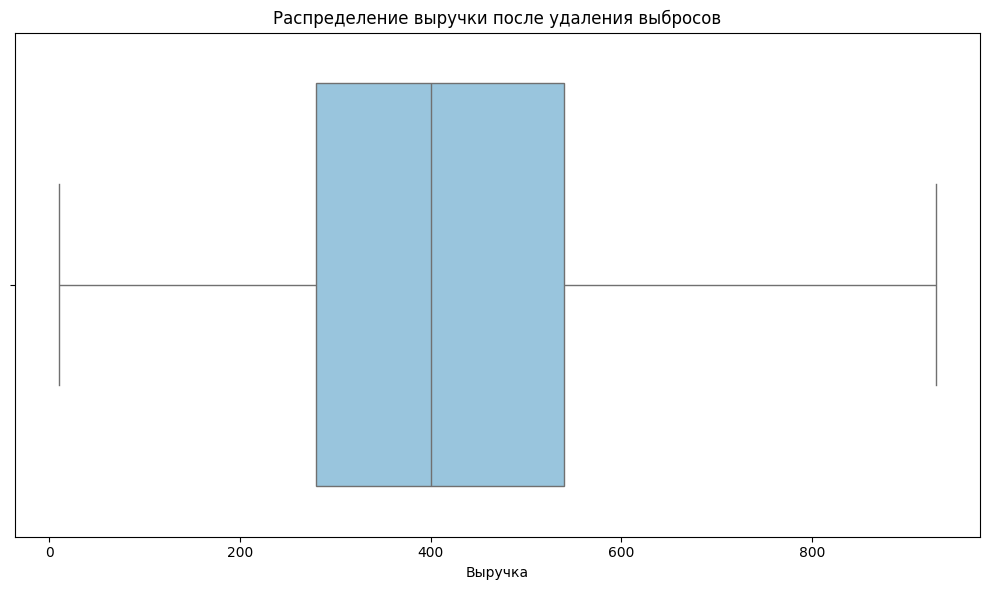

In [57]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    x=df_good['REVENUE_AMOUNT'],
    color='#8EC8E8'
)

plt.title('Распределение выручки после удаления выбросов')
plt.xlabel('Выручка')

plt.tight_layout()
plt.show()

In [58]:
# Определение выбросов с помощью сигм
mean = df['REVENUE_AMOUNT'].mean()
std = df['REVENUE_AMOUNT'].std()

lower_bound = mean - 3 * std
upper_bound = mean + 3 * std

print (lower_bound, upper_bound)

-206.73667516693945 1082.3341797600226


In [59]:
n_ejection = df['REVENUE_AMOUNT'][(df['REVENUE_AMOUNT'] > upper_bound) | (df['REVENUE_AMOUNT'] < lower_bound)].count()
print('Число выбросов:', n_ejection)

Число выбросов: 472


In [60]:
df_filtered = df[(df['REVENUE_AMOUNT'] >= lower_bound) & (df['REVENUE_AMOUNT'] <= upper_bound)]

n_ejection = df_filtered['REVENUE_AMOUNT'][(df_filtered['REVENUE_AMOUNT'] > upper_bound) | (df_filtered['REVENUE_AMOUNT'] < lower_bound)].count()
print('Число выбросов:', n_ejection)

Число выбросов: 0


In [61]:
df_filtered['REVENUE_AMOUNT'].describe()

,REVENUE_AMOUNT
count,49059.000000
mean,428.171385
std,187.345983
min,10.000000
25%,290.000000
50%,400.000000
75%,540.000000
max,1080.000000


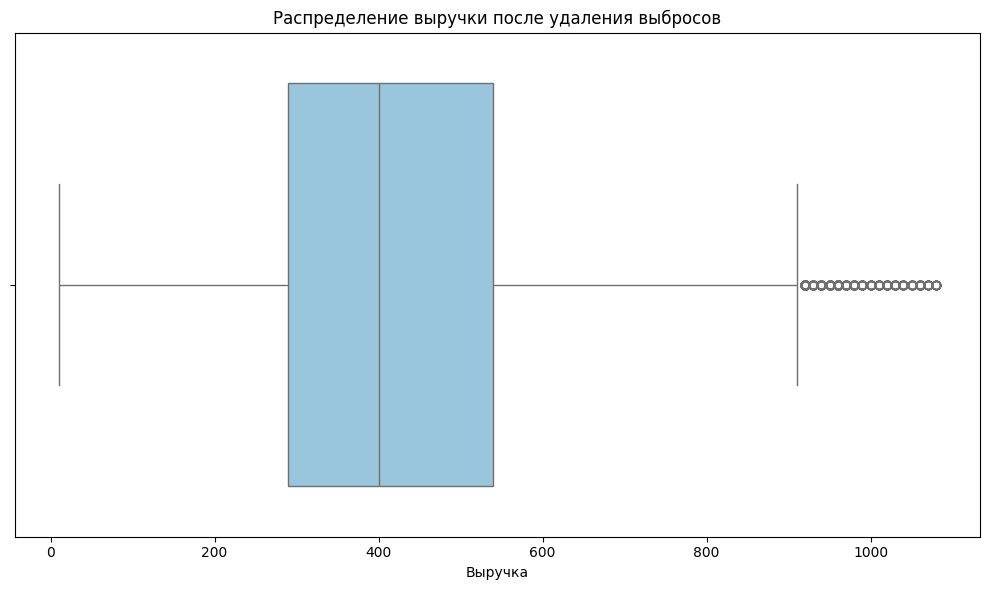

In [62]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    x=df_filtered['REVENUE_AMOUNT'],
    color='#8EC8E8'
)

plt.title('Распределение выручки после удаления выбросов')
plt.xlabel('Выручка')

plt.tight_layout()
plt.show()

In [63]:
lower_bound_99 = df['REVENUE_AMOUNT'].quantile(0.01)
upper_bound_99 = df['REVENUE_AMOUNT'].quantile(0.99)

n_ejection = df['REVENUE_AMOUNT'][(df['REVENUE_AMOUNT'] > upper_bound_99) | (df['REVENUE_AMOUNT'] < lower_bound_99)].count()
print('Число выбросов:', n_ejection)

Число выбросов: 816


In [64]:
df_filtered_99 = df[(df['REVENUE_AMOUNT'] >= lower_bound_99) & (df['REVENUE_AMOUNT'] <= upper_bound_99)]

n_ejection = df_filtered_99['REVENUE_AMOUNT'][(df_filtered_99['REVENUE_AMOUNT'] > upper_bound_99) | (df_filtered_99['REVENUE_AMOUNT'] < lower_bound_99)].count()
print('Число выбросов:', n_ejection)

Число выбросов: 0


In [65]:
df_filtered_99['REVENUE_AMOUNT'].describe()

,REVENUE_AMOUNT
count,48715.000000
mean,430.361490
std,185.421956
min,110.000000
25%,290.000000
50%,400.000000
75%,540.000000
max,1070.000000


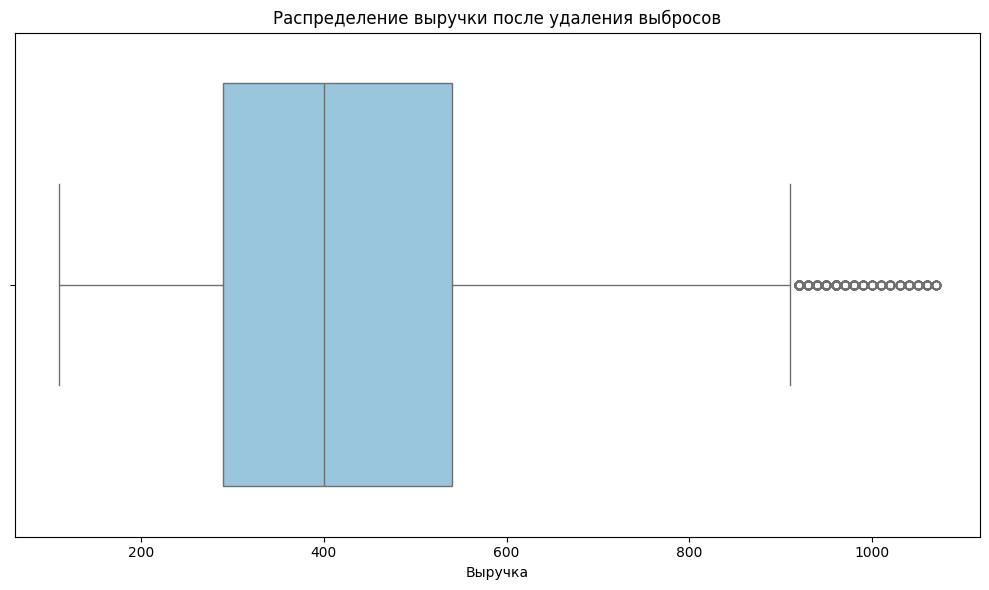

In [66]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    x=df_filtered_99['REVENUE_AMOUNT'],
    color='#8EC8E8'
)

plt.title('Распределение выручки после удаления выбросов')
plt.xlabel('Выручка')

plt.tight_layout()
plt.show()

Выводы:

Если взглянуть на боксплоты, то можно увидеть, что изначально в датасете довольно много выбросов, что лучше исправить. Я проверила три способа и в итоге остановилась на способе трех сигм (второй способ), так как там устраняется меньшее количество выбросов, а нам как раз нужно минимизировать потери данных по заданию. Некоторые выбросы возможны, так как на выручку с продажи авиабилетов влияли сезонность и политические обстоятельства

In [67]:
df_filtered['MONTH'] = pd.DatetimeIndex(df_filtered['ISSUE_DATE_YM']).month
df_filtered.head()

/tmp/ipykernel_1394/1933914648.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['MONTH'] = pd.DatetimeIndex(df_filtered['ISSUE_DATE_YM']).month


,ISSUE_DATE,FLIGHT_DATE_LOC,PAX_TYPE,REVENUE_AMOUNT,ORIG_CITY_CODE,DEST_CITY_CODE,ROUTE_FLIGHT_TYPE,FFP_FLAG,SALE_TYPE,ISSUE_DATE_YM,MONTH
0,2021-12-07,2022-01-11,AD,200,MOW,KGD,ВВЛ,NO,ONLINE,2021-12,12
1,2021-12-31,2022-01-03,AD,610,UUS,OVB,ВВЛ,NO,OFFLINE,2021-12,12
2,2021-11-28,2022-01-04,AD,390,KGD,MOW,ВВЛ,FFP,ONLINE,2021-11,11
3,2021-12-08,2022-01-05,AD,190,VOZ,MOW,ВВЛ,NO,ONLINE,2021-12,12
4,2021-12-08,2022-01-12,AD,190,MOW,KRR,ВВЛ,FFP,OFFLINE,2021-12,12


In [68]:
months = {
    1: 'JANUARY',
    2: 'FEBRUARY',
    3: 'MARCH',
    4: 'APRIL',
    5: 'MAY',
    6: 'JUNE',
    7: 'JULY',
    8: 'AUGUST',
    9: 'SEPTEMBER',
    10: 'OCTOBER',
    11: 'NOVEMBER',
    12: 'DECEMBER'
}

df_filtered['MONTH_NAME'] = df_filtered['MONTH'].map(months)
df_filtered.head()

/tmp/ipykernel_1394/2350887871.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['MONTH_NAME'] = df_filtered['MONTH'].map(months)


,ISSUE_DATE,FLIGHT_DATE_LOC,PAX_TYPE,REVENUE_AMOUNT,ORIG_CITY_CODE,DEST_CITY_CODE,ROUTE_FLIGHT_TYPE,FFP_FLAG,SALE_TYPE,ISSUE_DATE_YM,MONTH,MONTH_NAME
0,2021-12-07,2022-01-11,AD,200,MOW,KGD,ВВЛ,NO,ONLINE,2021-12,12,DECEMBER
1,2021-12-31,2022-01-03,AD,610,UUS,OVB,ВВЛ,NO,OFFLINE,2021-12,12,DECEMBER
2,2021-11-28,2022-01-04,AD,390,KGD,MOW,ВВЛ,FFP,ONLINE,2021-11,11,NOVEMBER
3,2021-12-08,2022-01-05,AD,190,VOZ,MOW,ВВЛ,NO,ONLINE,2021-12,12,DECEMBER
4,2021-12-08,2022-01-12,AD,190,MOW,KRR,ВВЛ,FFP,OFFLINE,2021-12,12,DECEMBER


In [69]:
season = {
    1: 'WINTER',
    2: 'WINTER',
    3: 'SPRING',
    4: 'SPRING',
    5: 'SPRING',
    6: 'SUMMER',
    7: 'SUMMER',
    8: 'SUMMER',
    9: 'AUTUMN',
    10: 'AUTUMN',
    11: 'AUTUMN',
    12: 'WINTER'
}

df_filtered['SEASON'] = df_filtered['MONTH'].map(season)
df_filtered.head()

/tmp/ipykernel_1394/2401760736.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['SEASON'] = df_filtered['MONTH'].map(season)


,ISSUE_DATE,FLIGHT_DATE_LOC,PAX_TYPE,REVENUE_AMOUNT,ORIG_CITY_CODE,DEST_CITY_CODE,ROUTE_FLIGHT_TYPE,FFP_FLAG,SALE_TYPE,ISSUE_DATE_YM,MONTH,MONTH_NAME,SEASON
0,2021-12-07,2022-01-11,AD,200,MOW,KGD,ВВЛ,NO,ONLINE,2021-12,12,DECEMBER,WINTER
1,2021-12-31,2022-01-03,AD,610,UUS,OVB,ВВЛ,NO,OFFLINE,2021-12,12,DECEMBER,WINTER
2,2021-11-28,2022-01-04,AD,390,KGD,MOW,ВВЛ,FFP,ONLINE,2021-11,11,NOVEMBER,AUTUMN
3,2021-12-08,2022-01-05,AD,190,VOZ,MOW,ВВЛ,NO,ONLINE,2021-12,12,DECEMBER,WINTER
4,2021-12-08,2022-01-12,AD,190,MOW,KRR,ВВЛ,FFP,OFFLINE,2021-12,12,DECEMBER,WINTER


In [70]:
month_order = ['OCTOBER', 'NOVEMBER', 'DECEMBER', 'JANUARY', 'FEBRUARY', 'MARCH', 'APRIL', 'MAY', 'JUNE', 'JULY', 'AUGUST', 'SEPTEMBER']

month_rev = (df_filtered.pivot_table(index='MONTH_NAME', aggfunc='sum', values='REVENUE_AMOUNT')).reset_index()

#делаем так, чтобы был порядок как в данных, самая ранняя дата там в октябре
month_rev['MONTH_NAME'] = pd.Categorical(month_rev['MONTH_NAME'], categories=month_order, ordered=True)

month_rev = month_rev.sort_values('MONTH_NAME')

month_rev.head()

,MONTH_NAME,REVENUE_AMOUNT
10,OCTOBER,1299710
9,NOVEMBER,1798720
2,DECEMBER,1717860
4,JANUARY,1325560
3,FEBRUARY,1317110


In [71]:
month_rev_count = (df_filtered.pivot_table(index='MONTH_NAME', aggfunc='count', values='REVENUE_AMOUNT')).reset_index()

month_rev_count['MONTH_NAME'] = pd.Categorical(month_rev_count['MONTH_NAME'], categories=month_order, ordered=True)

month_rev_count = month_rev_count.sort_values('MONTH_NAME')

month_rev_count.head()

,MONTH_NAME,REVENUE_AMOUNT
10,OCTOBER,3602
9,NOVEMBER,5152
2,DECEMBER,4552
4,JANUARY,3584
3,FEBRUARY,3443


In [72]:
month_rev_sc = month_rev.merge(month_rev_count, on='MONTH_NAME')

month_rev_sc = month_rev_sc.rename(columns={
    'REVENUE_AMOUNT_x': 'REVENUE_AMOUNT',
    'REVENUE_AMOUNT_y': 'SALES_COUNT'
})

month_rev_sc.head()

,MONTH_NAME,REVENUE_AMOUNT,SALES_COUNT
0,OCTOBER,1299710,3602
1,NOVEMBER,1798720,5152
2,DECEMBER,1717860,4552
3,JANUARY,1325560,3584
4,FEBRUARY,1317110,3443


In [73]:
season_order = ['AUTUMN', 'WINTER', 'SPRING', 'SUMMER']

season_rev = (df_filtered.pivot_table(index='SEASON', aggfunc='sum', values='REVENUE_AMOUNT')).reset_index()

season_rev['SEASON'] = pd.Categorical(season_rev['SEASON'], categories=season_order, ordered=True)

season_rev = season_rev.sort_values('SEASON')

season_rev.head()

,SEASON,REVENUE_AMOUNT
0,AUTUMN,4687690
3,WINTER,4360530
1,SPRING,5481710
2,SUMMER,6475730


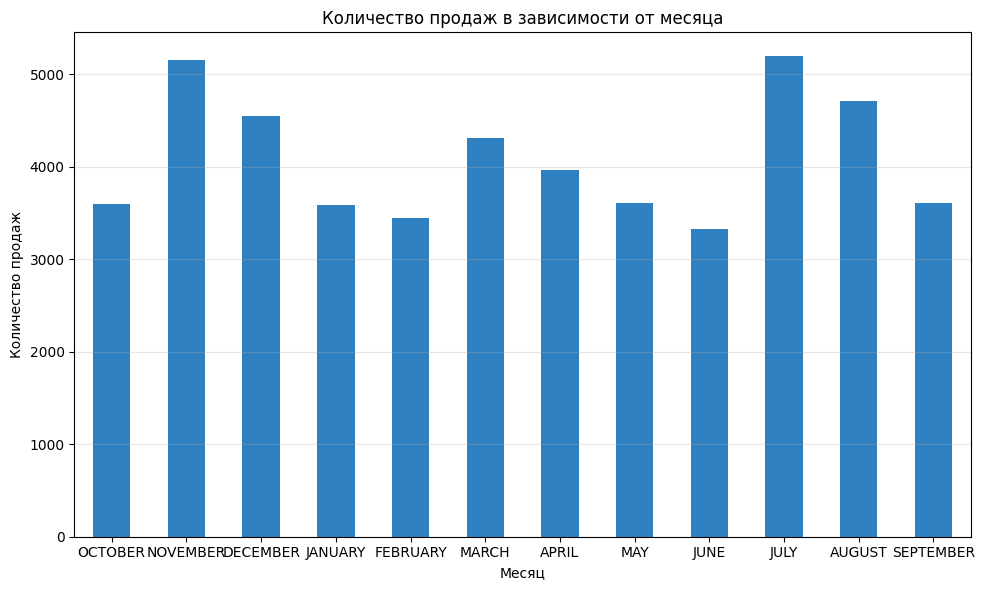

In [74]:
ax = month_rev_count.plot(
    kind='bar',
    figsize=(10, 6),
    x='MONTH_NAME',
    y='REVENUE_AMOUNT',
    color='#2F80C0',
    legend=False
)

ax.set_title('Количество продаж в зависимости от месяца')
ax.set_xlabel('Месяц')
ax.set_ylabel('Количество продаж')

ax.grid(axis='y', alpha=0.3)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

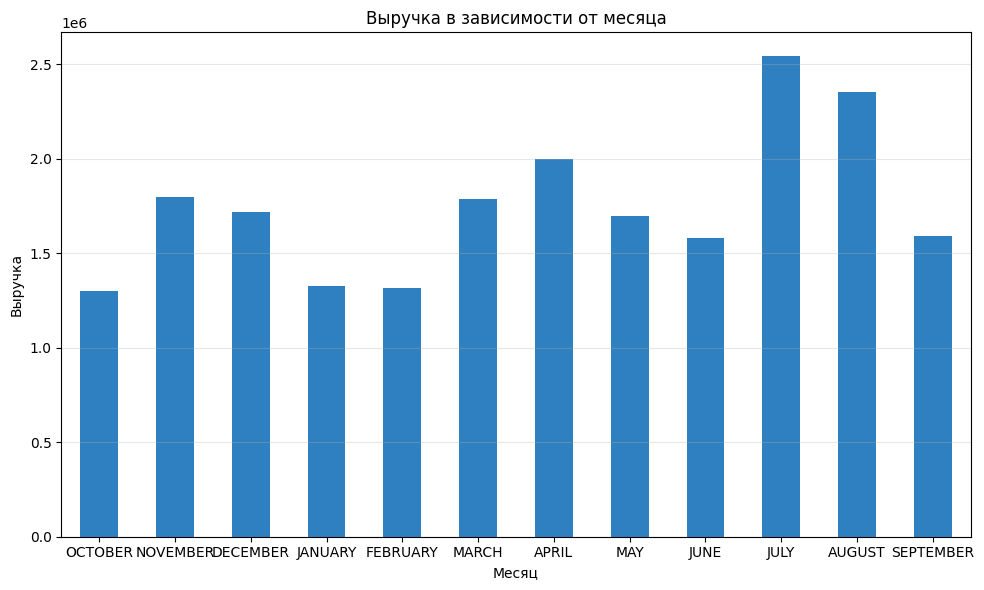

In [75]:
ax = month_rev.plot(
    kind='bar',
    figsize=(10, 6),
    x='MONTH_NAME',
    y='REVENUE_AMOUNT',
    color='#2F80C0',
    legend=False
)

ax.set_title('Выручка в зависимости от месяца')
ax.set_xlabel('Месяц')
ax.set_ylabel('Выручка')

ax.grid(axis='y', alpha=0.3)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

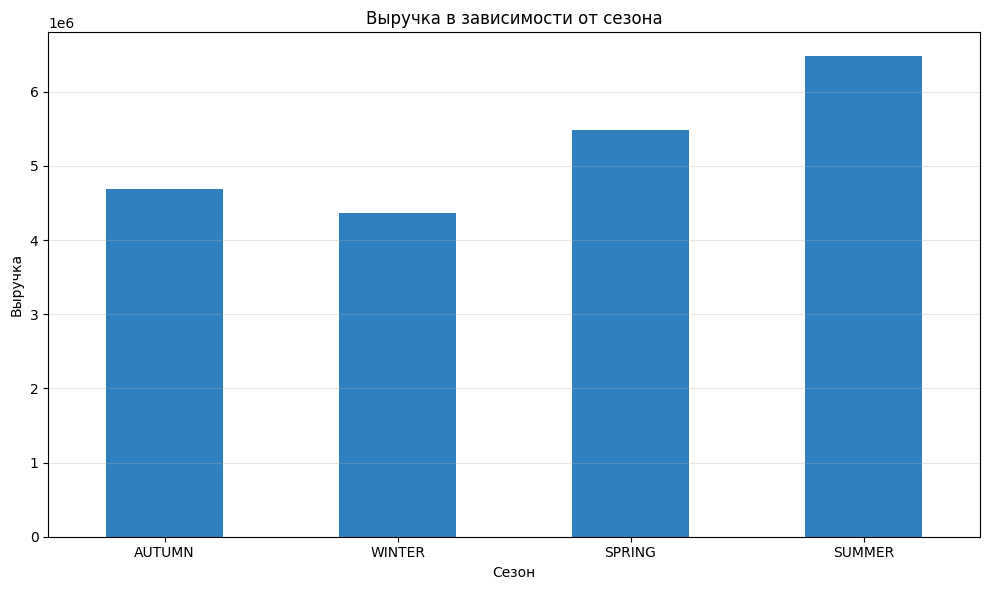

In [76]:
ax = season_rev.plot(
    kind='bar',
    figsize=(10, 6),
    x='SEASON',
    y='REVENUE_AMOUNT',
    color='#2F80C0',
    legend=False
)

ax.set_title('Выручка в зависимости от сезона')
ax.set_xlabel('Сезон')
ax.set_ylabel('Выручка')

ax.grid(axis='y', alpha=0.3)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [77]:
corr = month_rev_sc[['SALES_COUNT', 'REVENUE_AMOUNT']].corr()
corr.round(3)

,SALES_COUNT,REVENUE_AMOUNT
SALES_COUNT,1.000,0.763
REVENUE_AMOUNT,0.763,1.000


In [78]:
winter_rev = df_filtered[df_filtered['SEASON'] == 'WINTER']['REVENUE_AMOUNT']
autumn_rev = df_filtered[df_filtered['SEASON'] == 'AUTUMN']['REVENUE_AMOUNT']

In [79]:
print(f"Осень: {len(autumn_rev)} наблюдений")
print(f"Зима: {len(winter_rev)} наблюдений")

Осень: 12365 наблюдений
Зима: 11579 наблюдений


In [80]:
# тест Шапиро-Уилка
stat, p = st.shapiro(winter_rev)

alpha = 0.05
if p < alpha:
    print(p, 'Отвергаем нулевую гипотезу. Выборка выручки от продажи билетов зимой НЕ имеет нормального распределения')
else:
    print(p, 'Не получилось отвергнуть нулевую гипотезу. Выборка выручки от продажи билетов зимой имеет нормальное распределение')

9.903094300686097e-53 Отвергаем нулевую гипотезу. Выборка выручки от продажи билетов зимой НЕ имеет нормального распределения


/usr/local/lib/python3.13/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 11579.
  res = hypotest_fun_out(*samples, **kwds)


In [81]:
# тест Шапиро-Уилка
stat, p = st.shapiro(autumn_rev)

alpha = 0.05
if p < alpha:
    print(p, 'Отвергаем нулевую гипотезу. Выборка выручки от продажи билетов осенью НЕ имеет нормального распределения')
else:
    print(p, 'Не получилось отвергнуть нулевую гипотезу. Выборка выручки от продажи билетов осенью имеет нормальное распределение')

1.1152522777473119e-53 Отвергаем нулевую гипотезу. Выборка выручки от продажи билетов осенью НЕ имеет нормального распределения


/usr/local/lib/python3.13/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 12365.
  res = hypotest_fun_out(*samples, **kwds)


In [82]:
# H0: Выручка от продаж зимой и осенью в среднем не отличается
# H1: Выручка от продаж зимой и осенью в среднем отличается

results = st.mannwhitneyu(winter_rev, autumn_rev)

print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу: Выручка от продаж зимой и осенью в среднем отличается')
else:
    print('Не получилось отвергнуть нулевую гипотезу: Выручка от продаж зимой и осенью в среднем не отличается')

p-value: 0.49473380178036064
Не получилось отвергнуть нулевую гипотезу: Выручка от продаж зимой и осенью в среднем не отличается


Выводы:

Исследуя сезонность продаж, то было замечено, что больше всего билетов приобреталось в июле, потому что сезон отпусков. А если говорить про времена города, то больше всего выручки получили летом тоже по этой причине. Если анализировать зависимость выручки от количество покупок билета, то коэффициент корреляции равен 0,763, что значит, что изменения в количестве продаж статистически сильно связаны с изменениями выручки, что позволяет прогнозировать рост выручки при увеличении продаж. При проверке гипотезы о различии выручки осенью и зимой, то выяснилось, что они не отличаются.Это выснилось благодаря тесту Манна-Уитни, так как у выборок нет нормального распределения, что выяснилось при проведении тестов Шапиро


In [83]:
df_filtered['BUY_TIME'] = (df_filtered['FLIGHT_DATE_LOC'] - df_filtered['ISSUE_DATE']).dt.days
df_filtered.head()

/tmp/ipykernel_1394/2724683754.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['BUY_TIME'] = (df_filtered['FLIGHT_DATE_LOC'] - df_filtered['ISSUE_DATE']).dt.days


,ISSUE_DATE,FLIGHT_DATE_LOC,PAX_TYPE,REVENUE_AMOUNT,ORIG_CITY_CODE,DEST_CITY_CODE,ROUTE_FLIGHT_TYPE,FFP_FLAG,SALE_TYPE,ISSUE_DATE_YM,MONTH,MONTH_NAME,SEASON,BUY_TIME
0,2021-12-07,2022-01-11,AD,200,MOW,KGD,ВВЛ,NO,ONLINE,2021-12,12,DECEMBER,WINTER,35
1,2021-12-31,2022-01-03,AD,610,UUS,OVB,ВВЛ,NO,OFFLINE,2021-12,12,DECEMBER,WINTER,3
2,2021-11-28,2022-01-04,AD,390,KGD,MOW,ВВЛ,FFP,ONLINE,2021-11,11,NOVEMBER,AUTUMN,37
3,2021-12-08,2022-01-05,AD,190,VOZ,MOW,ВВЛ,NO,ONLINE,2021-12,12,DECEMBER,WINTER,28
4,2021-12-08,2022-01-12,AD,190,MOW,KRR,ВВЛ,FFP,OFFLINE,2021-12,12,DECEMBER,WINTER,35


In [84]:
recency_25 = df_filtered['BUY_TIME'].describe()['25%']
recency_75 = df_filtered['BUY_TIME'].describe()['75%']

print(recency_25)
print(recency_75)

3.0
25.0


In [85]:
def recency(days):

    if days <= recency_25:
        return 1
    elif recency_25 < days <= recency_75:
        return 2
    elif recency_75 < days:
        return 3
    else:
        return np.nan

In [86]:
df_filtered['RECENCY'] = df_filtered['BUY_TIME'].apply(recency)
df_filtered.head()

/tmp/ipykernel_1394/3211269314.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['RECENCY'] = df_filtered['BUY_TIME'].apply(recency)


,ISSUE_DATE,FLIGHT_DATE_LOC,PAX_TYPE,REVENUE_AMOUNT,ORIG_CITY_CODE,DEST_CITY_CODE,ROUTE_FLIGHT_TYPE,FFP_FLAG,SALE_TYPE,ISSUE_DATE_YM,MONTH,MONTH_NAME,SEASON,BUY_TIME,RECENCY
0,2021-12-07,2022-01-11,AD,200,MOW,KGD,ВВЛ,NO,ONLINE,2021-12,12,DECEMBER,WINTER,35,3
1,2021-12-31,2022-01-03,AD,610,UUS,OVB,ВВЛ,NO,OFFLINE,2021-12,12,DECEMBER,WINTER,3,1
2,2021-11-28,2022-01-04,AD,390,KGD,MOW,ВВЛ,FFP,ONLINE,2021-11,11,NOVEMBER,AUTUMN,37,3
3,2021-12-08,2022-01-05,AD,190,VOZ,MOW,ВВЛ,NO,ONLINE,2021-12,12,DECEMBER,WINTER,28,3
4,2021-12-08,2022-01-12,AD,190,MOW,KRR,ВВЛ,FFP,OFFLINE,2021-12,12,DECEMBER,WINTER,35,3


In [87]:
recency_w = {
    1: 'LATE',
    2: 'NORMAL',
    3: 'EARLY'
}

df_filtered['RECENCY_NAME'] = df_filtered['RECENCY'].map(recency_w)
df_filtered.head()

/tmp/ipykernel_1394/28577554.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['RECENCY_NAME'] = df_filtered['RECENCY'].map(recency_w)


,ISSUE_DATE,FLIGHT_DATE_LOC,PAX_TYPE,REVENUE_AMOUNT,ORIG_CITY_CODE,DEST_CITY_CODE,ROUTE_FLIGHT_TYPE,FFP_FLAG,SALE_TYPE,ISSUE_DATE_YM,MONTH,MONTH_NAME,SEASON,BUY_TIME,RECENCY,RECENCY_NAME
0,2021-12-07,2022-01-11,AD,200,MOW,KGD,ВВЛ,NO,ONLINE,2021-12,12,DECEMBER,WINTER,35,3,EARLY
1,2021-12-31,2022-01-03,AD,610,UUS,OVB,ВВЛ,NO,OFFLINE,2021-12,12,DECEMBER,WINTER,3,1,LATE
2,2021-11-28,2022-01-04,AD,390,KGD,MOW,ВВЛ,FFP,ONLINE,2021-11,11,NOVEMBER,AUTUMN,37,3,EARLY
3,2021-12-08,2022-01-05,AD,190,VOZ,MOW,ВВЛ,NO,ONLINE,2021-12,12,DECEMBER,WINTER,28,3,EARLY
4,2021-12-08,2022-01-12,AD,190,MOW,KRR,ВВЛ,FFP,OFFLINE,2021-12,12,DECEMBER,WINTER,35,3,EARLY


In [88]:
df_filtered_recency = df_filtered.pivot_table(index='RECENCY_NAME', aggfunc='sum', values='REVENUE_AMOUNT').reset_index()
df_filtered_recency.head()

,RECENCY_NAME,REVENUE_AMOUNT
0,EARLY,5224760
1,LATE,5100840
2,NORMAL,10680060


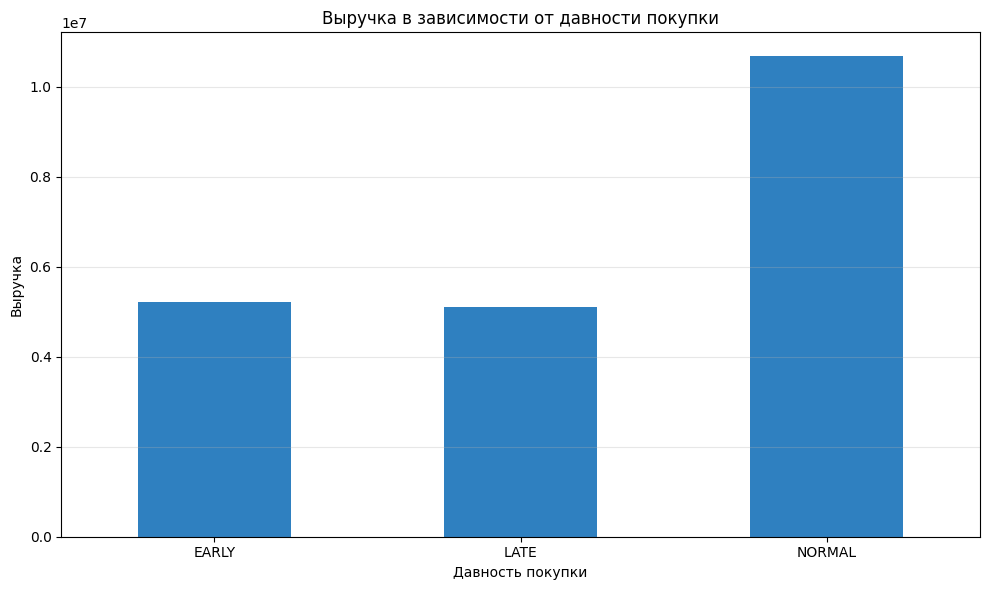

In [89]:
ax = df_filtered_recency.plot(
    kind='bar',
    figsize=(10, 6),
    x='RECENCY_NAME',
    y='REVENUE_AMOUNT',
    color='#2F80C0',
    legend=False
)

ax.set_title('Выручка в зависимости от давности покупки')
ax.set_xlabel('Давность покупки')
ax.set_ylabel('Выручка')

ax.grid(axis='y', alpha=0.3)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Выводы:

Было принято решение разделить пассажиров на 3 категории: те, кто покупает билеты минимум за 25 дней, то есть заранее, кто покупает билеты +/- вовремя, в промежутке между 3-25 днями, и поздно – за дня 3 и позже до вылета. Выяснилось, что большее количество людей покупают билеты +/- вовремя, да 3-25 дней до вылета

In [99]:
airports = pd.read_csv('airports.dat.txt', header=None)

columns = ['INDEX', 'AIRPORT_NAME', 'LOCATION', 'COUNTRY', 'IATA_CODE', 'ICAO_CODE', 'LATITUDE', 'LONGITUDE', 'ALTITUDE', 'TIMEZONE', 'DST', 'TIMEZONE_REGION', 'TYPE', 'SOURCE']

airports.columns = columns

airports.head()

,INDEX,AIRPORT_NAME,LOCATION,COUNTRY,IATA_CODE,ICAO_CODE,LATITUDE,LONGITUDE,ALTITUDE,TIMEZONE,DST,TIMEZONE_REGION,TYPE,SOURCE
0,1,Goroka Airport,Goroka,Papua New Guinea,GKA,AYGA,-6.081690,145.391998,5282,10,U,Pacific/Port_Moresby,airport,OurAirports
1,2,Madang Airport,Madang,Papua New Guinea,MAG,AYMD,-5.207080,145.789001,20,10,U,Pacific/Port_Moresby,airport,OurAirports
2,3,Mount Hagen Kagamuga Airport,Mount Hagen,Papua New Guinea,HGU,AYMH,-5.826790,144.296005,5388,10,U,Pacific/Port_Moresby,airport,OurAirports
3,4,Nadzab Airport,Nadzab,Papua New Guinea,LAE,AYNZ,-6.569803,146.725977,239,10,U,Pacific/Port_Moresby,airport,OurAirports
4,5,Port Moresby Jacksons International Airport,Port Moresby,Papua New Guinea,POM,AYPY,-9.443380,147.220001,146,10,U,Pacific/Port_Moresby,airport,OurAirports


In [100]:
airports_filtered = airports[['LOCATION', 'IATA_CODE']]

airports_filtered.head()

,LOCATION,IATA_CODE
0,Goroka,GKA
1,Madang,MAG
2,Mount Hagen,HGU
3,Nadzab,LAE
4,Port Moresby,POM


In [101]:
airports_orig = airports_filtered.rename(columns={'IATA_CODE': 'ORIG_CITY_CODE', 'LOCATION': 'ORIG_CITY_NAME'})
airports_dest = airports_filtered.rename(columns={'IATA_CODE': 'DEST_CITY_CODE', 'LOCATION': 'DEST_CITY_NAME'})

df_filtered = df_filtered.merge(airports_orig[['ORIG_CITY_CODE', 'ORIG_CITY_NAME']], on='ORIG_CITY_CODE', how='left')

df_filtered = df_filtered.merge(airports_dest[['DEST_CITY_CODE', 'DEST_CITY_NAME']], on='DEST_CITY_CODE', how='left')

df_filtered.head()

,ISSUE_DATE,FLIGHT_DATE_LOC,PAX_TYPE,REVENUE_AMOUNT,ORIG_CITY_CODE,DEST_CITY_CODE,ROUTE_FLIGHT_TYPE,FFP_FLAG,SALE_TYPE,ISSUE_DATE_YM,MONTH,MONTH_NAME,SEASON,BUY_TIME,RECENCY,RECENCY_NAME,ORIG_CITY_NAME,DEST_CITY_NAME
0,2021-12-07,2022-01-11,AD,200,MOW,KGD,ВВЛ,NO,ONLINE,2021-12,12,DECEMBER,WINTER,35,3,EARLY,NaN,Kaliningrad
1,2021-12-31,2022-01-03,AD,610,UUS,OVB,ВВЛ,NO,OFFLINE,2021-12,12,DECEMBER,WINTER,3,1,LATE,Yuzhno-sakhalinsk,Novosibirsk
2,2021-11-28,2022-01-04,AD,390,KGD,MOW,ВВЛ,FFP,ONLINE,2021-11,11,NOVEMBER,AUTUMN,37,3,EARLY,Kaliningrad,NaN
3,2021-12-08,2022-01-05,AD,190,VOZ,MOW,ВВЛ,NO,ONLINE,2021-12,12,DECEMBER,WINTER,28,3,EARLY,Voronezh,NaN
4,2021-12-08,2022-01-12,AD,190,MOW,KRR,ВВЛ,FFP,OFFLINE,2021-12,12,DECEMBER,WINTER,35,3,EARLY,NaN,Krasnodar


In [102]:
df_filtered[df_filtered[['ORIG_CITY_NAME', 'DEST_CITY_NAME']].isnull().any(axis=1)].head()

,ISSUE_DATE,FLIGHT_DATE_LOC,PAX_TYPE,REVENUE_AMOUNT,ORIG_CITY_CODE,DEST_CITY_CODE,ROUTE_FLIGHT_TYPE,FFP_FLAG,SALE_TYPE,ISSUE_DATE_YM,MONTH,MONTH_NAME,SEASON,BUY_TIME,RECENCY,RECENCY_NAME,ORIG_CITY_NAME,DEST_CITY_NAME
0,2021-12-07,2022-01-11,AD,200,MOW,KGD,ВВЛ,NO,ONLINE,2021-12,12,DECEMBER,WINTER,35,3,EARLY,NaN,Kaliningrad
2,2021-11-28,2022-01-04,AD,390,KGD,MOW,ВВЛ,FFP,ONLINE,2021-11,11,NOVEMBER,AUTUMN,37,3,EARLY,Kaliningrad,NaN
3,2021-12-08,2022-01-05,AD,190,VOZ,MOW,ВВЛ,NO,ONLINE,2021-12,12,DECEMBER,WINTER,28,3,EARLY,Voronezh,NaN
4,2021-12-08,2022-01-12,AD,190,MOW,KRR,ВВЛ,FFP,OFFLINE,2021-12,12,DECEMBER,WINTER,35,3,EARLY,NaN,Krasnodar
5,2021-11-29,2022-01-14,AD,250,MOW,DUS,МВЛ,NO,ONLINE,2021-11,11,NOVEMBER,AUTUMN,46,3,EARLY,NaN,Duesseldorf


In [103]:
missing_orig_codes = df_filtered.loc[df_filtered['ORIG_CITY_NAME'].isnull(), 'ORIG_CITY_CODE'].unique()
missing_orig_codes

array(['MOW', 'PAR', 'BAK', 'ROM', 'SEL', 'BER', 'GRV', 'NQZ', 'OHH',
       'TOX', 'MIL', 'TYO', 'LON'], dtype=object)

In [104]:
missing_dest_codes = df_filtered.loc[df_filtered['DEST_CITY_NAME'].isnull(), 'DEST_CITY_CODE'].unique()
missing_dest_codes

array(['MOW', 'BAK', 'GRV', 'BER', 'TOX', 'NQZ', 'ROM', 'SEL', 'PAR',
       'LON', 'TYO', 'MIL'], dtype=object)

In [105]:
code_city = {
    'MOW': 'Moscow',
    'PAR': 'Paris',
    'BAK': 'Baku',
    'ROM': 'Rome',
    'SEL': 'Seoul',
    'BER': 'Berlin',
    'GRV': 'Grozny',
    'NQZ': 'Nur-Sultan',
    'OHH': 'Okha',
    'TOX': 'Tobolsk',
    'MIL': 'Milan',
    'TYO': 'Tokyo',
    'LON': 'London'
}

df_filtered['ORIG_CITY_NAME'] = df_filtered['ORIG_CITY_NAME'].fillna(df_filtered['ORIG_CITY_CODE'].map(code_city))
df_filtered['DEST_CITY_NAME'] = df_filtered['DEST_CITY_NAME'].fillna(df_filtered['DEST_CITY_CODE'].map(code_city))

In [106]:
df_filtered.head()

,ISSUE_DATE,FLIGHT_DATE_LOC,PAX_TYPE,REVENUE_AMOUNT,ORIG_CITY_CODE,DEST_CITY_CODE,ROUTE_FLIGHT_TYPE,FFP_FLAG,SALE_TYPE,ISSUE_DATE_YM,MONTH,MONTH_NAME,SEASON,BUY_TIME,RECENCY,RECENCY_NAME,ORIG_CITY_NAME,DEST_CITY_NAME
0,2021-12-07,2022-01-11,AD,200,MOW,KGD,ВВЛ,NO,ONLINE,2021-12,12,DECEMBER,WINTER,35,3,EARLY,Moscow,Kaliningrad
1,2021-12-31,2022-01-03,AD,610,UUS,OVB,ВВЛ,NO,OFFLINE,2021-12,12,DECEMBER,WINTER,3,1,LATE,Yuzhno-sakhalinsk,Novosibirsk
2,2021-11-28,2022-01-04,AD,390,KGD,MOW,ВВЛ,FFP,ONLINE,2021-11,11,NOVEMBER,AUTUMN,37,3,EARLY,Kaliningrad,Moscow
3,2021-12-08,2022-01-05,AD,190,VOZ,MOW,ВВЛ,NO,ONLINE,2021-12,12,DECEMBER,WINTER,28,3,EARLY,Voronezh,Moscow
4,2021-12-08,2022-01-12,AD,190,MOW,KRR,ВВЛ,FFP,OFFLINE,2021-12,12,DECEMBER,WINTER,35,3,EARLY,Moscow,Krasnodar


In [107]:
df_filtered[df_filtered[['ORIG_CITY_NAME', 'DEST_CITY_NAME']].isnull().any(axis=1)].head()

,ISSUE_DATE,FLIGHT_DATE_LOC,PAX_TYPE,REVENUE_AMOUNT,ORIG_CITY_CODE,DEST_CITY_CODE,ROUTE_FLIGHT_TYPE,FFP_FLAG,SALE_TYPE,ISSUE_DATE_YM,MONTH,MONTH_NAME,SEASON,BUY_TIME,RECENCY,RECENCY_NAME,ORIG_CITY_NAME,DEST_CITY_NAME


In [108]:
orig_city_name = df_filtered['ORIG_CITY_NAME']
dest_city_name = df_filtered['DEST_CITY_NAME']

df_filtered['FLIGHT_WAY'] = orig_city_name + ' - ' + dest_city_name

df_filtered.head()

,ISSUE_DATE,FLIGHT_DATE_LOC,PAX_TYPE,REVENUE_AMOUNT,ORIG_CITY_CODE,DEST_CITY_CODE,ROUTE_FLIGHT_TYPE,FFP_FLAG,SALE_TYPE,ISSUE_DATE_YM,MONTH,MONTH_NAME,SEASON,BUY_TIME,RECENCY,RECENCY_NAME,ORIG_CITY_NAME,DEST_CITY_NAME,FLIGHT_WAY
0,2021-12-07,2022-01-11,AD,200,MOW,KGD,ВВЛ,NO,ONLINE,2021-12,12,DECEMBER,WINTER,35,3,EARLY,Moscow,Kaliningrad,Moscow - Kaliningrad
1,2021-12-31,2022-01-03,AD,610,UUS,OVB,ВВЛ,NO,OFFLINE,2021-12,12,DECEMBER,WINTER,3,1,LATE,Yuzhno-sakhalinsk,Novosibirsk,Yuzhno-sakhalinsk - Novosibirsk
2,2021-11-28,2022-01-04,AD,390,KGD,MOW,ВВЛ,FFP,ONLINE,2021-11,11,NOVEMBER,AUTUMN,37,3,EARLY,Kaliningrad,Moscow,Kaliningrad - Moscow
3,2021-12-08,2022-01-05,AD,190,VOZ,MOW,ВВЛ,NO,ONLINE,2021-12,12,DECEMBER,WINTER,28,3,EARLY,Voronezh,Moscow,Voronezh - Moscow
4,2021-12-08,2022-01-12,AD,190,MOW,KRR,ВВЛ,FFP,OFFLINE,2021-12,12,DECEMBER,WINTER,35,3,EARLY,Moscow,Krasnodar,Moscow - Krasnodar


In [109]:
top_10_vvl = (df_filtered[df_filtered['ROUTE_FLIGHT_TYPE'] == 'ВВЛ']['FLIGHT_WAY'].value_counts().reset_index().head(10))
print(top_10_vvl)

                FLIGHT_WAY  count
0           Sochi - Moscow   1332
1           Moscow - Sochi   1303
2  St. Petersburg - Moscow   1216
3  Moscow - St. Petersburg   1198
4     Novosibirsk - Moscow    969
5     Moscow - Novosibirsk    950
6           Moscow - Kazan    764
7           Kazan - Moscow    763
8             Moscow - Ufa    710
9      Novosibirsk - Sochi    675


In [110]:
top_10_vvl_sum = (df_filtered[df_filtered['ROUTE_FLIGHT_TYPE'] == 'ВВЛ'].groupby('FLIGHT_WAY')['REVENUE_AMOUNT'].sum().reset_index())

top_10_vvl = top_10_vvl.merge(top_10_vvl_sum, on='FLIGHT_WAY', how='left')

top_10_vvl

,FLIGHT_WAY,count,REVENUE_AMOUNT
0,Sochi - Moscow,1332,518420
1,Moscow - Sochi,1303,490230
2,St. Petersburg - Moscow,1216,281760
3,Moscow - St. Petersburg,1198,277260
4,Novosibirsk - Moscow,969,461650
5,Moscow - Novosibirsk,950,443880
6,Moscow - Kazan,764,206440
7,Kazan - Moscow,763,206160
8,Moscow - Ufa,710,211310
9,Novosibirsk - Sochi,675,389360


In [111]:
top_10_mvl = (df_filtered[df_filtered['ROUTE_FLIGHT_TYPE'] == 'МВЛ']['FLIGHT_WAY'].value_counts().reset_index().head(10))
print(top_10_mvl)

                FLIGHT_WAY  count
0             Moscow - Osh    153
1       Khudzhand - Moscow    147
2             Osh - Moscow    137
3       Moscow - Khudzhand    130
4    Novosibirsk - Bishkek    120
5        Novosibirsk - Osh    119
6        Osh - Novosibirsk    118
7  Khudzhand - Novosibirsk    116
8    Bishkek - Novosibirsk    102
9         Moscow - Antalya    102


In [112]:
top_10_mvl_sum = (df_filtered[df_filtered['ROUTE_FLIGHT_TYPE'] == 'МВЛ'].groupby('FLIGHT_WAY')['REVENUE_AMOUNT'].sum().reset_index())

top_10_mvl = top_10_mvl.merge(top_10_mvl_sum, on='FLIGHT_WAY', how='left')

top_10_mvl

,FLIGHT_WAY,count,REVENUE_AMOUNT
0,Moscow - Osh,153,69610
1,Khudzhand - Moscow,147,97920
2,Osh - Moscow,137,81560
3,Moscow - Khudzhand,130,58750
4,Novosibirsk - Bishkek,120,46980
5,Novosibirsk - Osh,119,47450
6,Osh - Novosibirsk,118,58930
7,Khudzhand - Novosibirsk,116,57740
8,Bishkek - Novosibirsk,102,48300
9,Moscow - Antalya,102,39130


Выводы:

Дальше была задача выяснить топ-10 направлений перелета внутри страны и для заграничных перелетов. Среди внутренних перелетов самыми популярными направлениями стали пути Сочи-Москва и Москва-Сочи, Санкт-Петербург-Москва и Москва-Санкт-Петербург. Это происходит, потому что это самые популярные направления для путешествий и отпусков. При этом выручки с перелетов из Новосибирска в Москву и наоборот выше, но это потому что такие дальние перелеты стоят в целом дороже

Если говорить про международные перелеты, то самыми популярными направлениями являются перелеты между крупными российскими городами (Москва, Новосибирск) и городами Таджикистана. Это связано с большим количеством мигрантов, которые переезжают в Россию или просто приезжают работать


In [113]:
sale_type = {'ONLINE': 1, 'OFFLINE': 0}

df_filtered['SALE_TYPE_CODE'] = df_filtered['SALE_TYPE'].map(sale_type)

corr1 = df_filtered[['SALE_TYPE_CODE', 'REVENUE_AMOUNT']].corr()
corr1.round(3)

,SALE_TYPE_CODE,REVENUE_AMOUNT
SALE_TYPE_CODE,1.000,-0.172
REVENUE_AMOUNT,-0.172,1.000


Выводы:

Еще одним фактором, который, в теории, может влиять на выручку с продажи авиабилетов – это тип продажи билетов, но коэффициент корреляции близок к нулю, поэтому нельзя сказать, что выручка от продажи авиабилетов зависит от типа их продажи.При этом офлайн-продажи демонстрируют статистически незначимое преимущество в среднем чеке по сравнению с онлайн-продажами

Общие выводы по работе:

Проанализированный датасет включает 50 тысяч записей о продаже авиабилетов. Обнаружены небольшие пропуски, которые обработаны без значительных потерь данных. Максимальные продажи зафиксированы в июле-августе 2022 года из-за изменений в туристическом поведении россиян после политических событий. Преобладает онлайн-продажа билетов, особенно в летний период. Большинство пассажиров приобретает билеты за 3-25 дней до вылета. Популярные направления — перелеты между Москвой, Питером, Сочи, Новосибирском и международными рейсами в Таджикистан. Программа лояльности практически не используется клиентами. Статистически значимой связи между типом продажи билетов и общим уровнем выручки не обнаружено. Для обработки выбросов применялся метод трех сигм, позволяющий сократить потери данных